In [1]:
%load_ext autoreload
%autoreload 2

## Dependencies

In [2]:
import os
import json
import pickle
import random
import warnings
import gc
from itertools import product

import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer
from einops import rearrange
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from IPython.display import HTML, display

from baukit import Trace, TraceDict
from utils import *

In [3]:
warnings.filterwarnings("ignore")
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'  # Suppress transformer warnings
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

transformers.logging.set_verbosity_error()

In [4]:
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED)

Set seed 42


In [5]:
MODELS = [
    "/project/jevans/tzhang3/models/Llama-2-7b-chat-hf",
    "/project/jevans/tzhang3/models/Llama-3.1-8B-Instruct",
    "/project/jevans/tzhang3/models/Qwen2.5-7B-Instruct",
    "/project/jevans/tzhang3/models/Qwen2.5-14B-Instruct"
]

## Data

In [6]:
df = pd.read_csv('./data/HS116_members.csv')
df = df.loc[pd.notnull(df.nominate_dim1)].reset_index(drop=True)
df['first_middle_name'] = df['bioname'].apply(lambda x: x.split(', ')[1])
df['first_name'] = df['first_middle_name'].apply(lambda x: x.split(' ')[0] + ' ' if ' ' in x else x + ' ')
df['middle_name'] = df['first_middle_name'].apply(lambda x: x.split(' ')[1][0] + '. ' if ' ' in x else '')
df['last_name'] = df['bioname'].apply(lambda x: x.split(', ')[0].lower().capitalize().strip())
df['fullname'] = df['first_name'] + df['middle_name'] + df['last_name']

In [7]:
adfontesmedia = pd.read_csv('./data/adfontesmedia.csv')

In [8]:
def build_politician_prompt(fullname: str) -> str:
    return (
        f"USER: Generate a statement by {fullname}, a politician in the United States.\n"
        f"ASSISTANT: In 2019, {fullname} said that"
    )

def build_news_prompt(source_name: str) -> str:
    return (
        f"USER: Generate a statement from a news source in the United States.\n"
        f"ASSISTANT: {source_name} reported that"
    )

def build_vote_prompt(fullname: str) -> str:
    return (
        f"USER: In the context of 2019 U.S. politics, if you were {fullname}, "
        f"who would you most likely vote for in the next U.S. presidential election: Joe Biden or Donald Trump?\n"
        f"ASSISTANT: The person would most likely vote for"
    )

# Generate prompts
prompts_politicians = df["fullname"].apply(build_politician_prompt)
labels = df["nominate_dim1"].astype(float).values
df_prompts_politicians = pd.DataFrame({"prompt": prompts_politicians, "label": labels})

prompts_news = adfontesmedia["moniker_name"].apply(build_news_prompt)
labels = adfontesmedia["bias_mean"].astype(float).values
df_prompts_news = pd.DataFrame({"prompt": prompts_news, "label": labels})

# Generate vote-style prompts for politicians
prompts_dw_vote = df["fullname"].apply(build_vote_prompt)
labels_dw_vote = df["nominate_dim1"].astype(float).values  # Reuse same labels (liberal-conservative)
df_prompts_dw_vote = pd.DataFrame({"prompt": prompts_dw_vote, "label": labels_dw_vote})


In [9]:
df_prompts_vote = pd.read_csv("data/vote_2020_dataset.csv")
df_prompts_vote

,prompt,label_text,label
0,"USER: Given the 2020 economic climate, who was...",Trump,1
1,"USER: With all factors of 2020 in mind, which ...",Trump,1
2,"USER: Reflecting on 2020, who should have led ...",Biden,-1
3,"USER: Reflecting on 2020, who should have led ...",Biden,-1
4,"USER: During the 2020 contest, who was your pr...",Biden,-1
...,...,...,...
595,USER: Pretend you're in the voting booth in 20...,Trump,1
596,"USER: Considering their 2020 platforms, who de...",Biden,-1
597,"USER: When deciding in 2020, which name would ...",Biden,-1
598,USER: Who would you vote for in the 2020 U.S. ...,Trump,1


In [10]:
df_anes = pd.read_csv("data/anes.csv")

# Prompt builder
def build_prompt(persona, query):
    return (
        f"USER: How would {persona} in the United States in 2019 answer the following question. "
        f"{query.strip()} "
        f"ASSISTANT: As {persona}, I would answer the question with a score of "
    )

prompts_anes = []
for _, row in df_anes.iterrows():
    domain, question = row['domain'], row['query']
    for persona in df['fullname'].tolist():
        prompts_anes.append(build_prompt(persona, question))

In [11]:
# Prompt builder
def build_prompt(alignment, query):
    return (
        f"USER: Generate a statement from the {alignment} on the following question in the United States. "
        # f"{query.strip()}\n"
        # f"Do you favor or oppose transgender bathrooms?\n"
        # f"Do you favor or oppose US military aid to Ukraine?\n"
        f"Do you favor or oppose buying green socks for Christmas?\n"
        f"ASSISTANT: In 2019, the {alignment} believes that"
    )
    
prompts_socks = []
for alignment in ["liberal", "conservative"]:
    prompts_socks.append(build_prompt(alignment, None))

In [12]:
def build_prompt(query):
    return (
        f"USER: In the context of 2019 U.S. politics, is the following statement biased and leaning toward a liberal or conservative viewpoint? "
        f"{query.strip()}\n"
        f"ASSISTANT: The statement is"
    )

df_bias = pd.read_csv("data/policy_statements_240.csv")

prompts_bias = []
for _, row in df_bias.iterrows():
    text = row['response']
    prompts_bias.append(build_prompt(text))

len(prompts_bias)

240

In [13]:
def build_vote_prompts(alignment: str):
    return [
        # 1-20
        f"USER: If you had to vote in the 2019 U.S. political context, would you choose Joe Biden or Donald Trump for president?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: In your opinion, who would be the better choice for the next U.S. president in 2020—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: In the 2019 U.S. political environment, who aligns more with your values—Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Given the candidates Joe Biden and Donald Trump, who would you vote for in the 2020 U.S. election?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Based on 2019 U.S. politics, which candidate would receive your vote: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: As a {alignment}, who would you feel more comfortable voting for in the 2020 U.S. presidential election—Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Reflecting on 2019 U.S. politics, who would a {alignment} likely cast their vote for: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Considering the policy debates of 2019, does Joe Biden or Donald Trump better represent your priorities?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Thinking about your economic preferences in 2019, would Biden or Trump get your vote?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Comparing leadership styles, who would you endorse for president in 2020: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Which candidates platform, Biden's or Trump's, resonates more with you based on 2019 issues?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who do you see as the stronger commander-in-chief choice for 2020—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: From a 2019 standpoint, who wins your support: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: If only Biden and Trump were on the ballot, who would you cast your 2020 vote for?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Looking at social issues debated in 2019, would Trump or Biden be your preferred candidate?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Whose foreign-policy approach in 2019 convinces you to vote for them—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Evaluating character and experience, do you lean toward Joe Biden or Donald Trump for president?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: As a {alignment} voter in 2019, whose vision for America is closer to yours: Trump's or Biden's?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Between Biden and Trump, who aligns better with your voting preference in 2019?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Given the challenges highlighted in 2019, who would you trust more to handle the 2020 presidency—Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        # 20-40
        f"USER: If faced with the 2020 U.S. presidential ballot, would you choose Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Which candidate do you think reflects your values more in 2019, Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Between Donald Trump and Joe Biden, who seems like the better leader to you in the 2020 election?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Considering the 2019 debates, who would be your choice for president: Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who would earn your confidence as president in 2020, Trump or Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Looking at the issues of 2019, would Joe Biden or Donald Trump better deserve your vote?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Imagine casting a ballot in 2020—would you pick Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who would you back as the stronger candidate for the presidency: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Thinking about 2019’s political climate, which candidate speaks more to your beliefs, Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: As a {alignment}, which candidate’s vision resonates with you in 2020: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: When comparing their agendas, who would you prefer as president—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Based on leadership qualities, who is your pick for the 2020 race: Trump or Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Between Joe Biden and Donald Trump, who would a {alignment} most likely vote for in 2019?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: If you were voting strictly on character, who would you support—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Considering domestic policy in 2019, would you side with Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who is the preferable commander-in-chief in your eyes: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: If only Biden and Trump were on the ticket, who would you choose for president?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Thinking as a {alignment}, whose 2019 platform better serves your priorities—Trump’s or Biden’s?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: When reflecting on 2019 politics, which candidate represents your stance: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: In your view, who is the right choice for the White House in 2020: Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
    ]

prompts_vote = []
meta_vote = []

for alignment in ["liberal", "conservative"]:
    for i, prompt in enumerate(build_vote_prompts(alignment)):
        prompts_vote.append(prompt)
        meta_vote.append({"prompt_id": i, "alignment": alignment})


In [14]:
def build_prompt(query):
    return (
        f"USER: In the context of 2019 U.S. politics, please rewrite the following statement to make it politically neutral and free from liberal or conservative bias:\n"
        f"\"{query.strip()}\"\n"
        f"ASSISTANT: Here's a neutral version of the text:"
    )

df_bias = pd.read_csv("data/policy_statements_240.csv")

prompts_rewrite = []
meta_rewrite = []

# df_bias = df_bias.sample(1, random_state=42)
for _, row in df_bias.iterrows():
    text = row['response']
    prompts_rewrite.append(build_prompt(text))
    meta_rewrite.append({"name": row["name"], "domain": row["domain"]})

In [15]:
def build_prompt(query, domain):
    return (
        f"USER: As a US politician, write a paragraph about {domain}:\n"
        f"ASSISTANT: {query}"
    )

df_statements_v2 = pd.read_csv("data/policy_statements_v2_600.csv")
name2dw = df[["nominate_dim1", "fullname"]].set_index("fullname")['nominate_dim1'].to_dict()

prompts_statements_v2 = []

for _, row in df_statements_v2.iterrows():
    name = row["name"]
    text = row['response']
    domain = row["domain"]
    label = name2dw[name]
    prompts_statements_v2.append({"prompt": build_prompt(text, domain), "name": name, "domain": domain, "label": label})

prompts_statements_v2 = pd.DataFrame(prompts_statements_v2)
prompts_statements_v2

,prompt,name,domain,label
0,"USER: As a US politician, write a paragraph ab...",Donald J. Trump,Abortion,0.403
1,"USER: As a US politician, write a paragraph ab...",Andrew S. Biggs,Abortion,0.827
2,"USER: As a US politician, write a paragraph ab...",Dan Meuser,Abortion,0.494
3,"USER: As a US politician, write a paragraph ab...",Joni Ernst,Abortion,0.531
4,"USER: As a US politician, write a paragraph ab...",Joseph D. Morelle,Abortion,-0.329
...,...,...,...,...
595,"USER: As a US politician, write a paragraph ab...",Raúl M. Grijalva,Gaza Humanitarian Aid,-0.598
596,"USER: As a US politician, write a paragraph ab...",Benjamin L. Cardin,Gaza Humanitarian Aid,-0.320
597,"USER: As a US politician, write a paragraph ab...",William M. Thornberry,Gaza Humanitarian Aid,0.525
598,"USER: As a US politician, write a paragraph ab...",David Rouzer,Gaza Humanitarian Aid,0.564


In [16]:
df_prompts_stances = pd.read_csv("data/policy_statements_synthetic_stance.csv")
df_prompts_stances

,domain,policy,stance,statement,prompt,label
0,Abortion,State authority to restrict or ban abortion,strongly object,I strongly oppose this policy and believe it w...,USER: Generate a statement about the following...,-1.0
1,Abortion,State authority to restrict or ban abortion,strongly object,This policy is fundamentally wrong and should ...,USER: Generate a statement about the following...,-1.0
2,Abortion,State authority to restrict or ban abortion,strongly object,I unequivocally reject this policy.,USER: Generate a statement about the following...,-1.0
3,Abortion,State authority to restrict or ban abortion,strongly object,This is a deeply misguided policy that must be...,USER: Generate a statement about the following...,-1.0
4,Abortion,State authority to restrict or ban abortion,strongly object,I am firmly against this policy in any form.,USER: Generate a statement about the following...,-1.0
...,...,...,...,...,...,...
2145,Gun,Opposing bail reform and emphasizing tough-on-...,strongly support,I strongly favor this policy and will actively...,USER: Generate a statement about the following...,1.0
2146,Gun,Opposing bail reform and emphasizing tough-on-...,strongly support,This is a critical policy that I strongly supp...,USER: Generate a statement about the following...,1.0
2147,Gun,Opposing bail reform and emphasizing tough-on-...,strongly support,I fully endorse this policy and its objectives.,USER: Generate a statement about the following...,1.0
2148,Gun,Opposing bail reform and emphasizing tough-on-...,strongly support,I’m a strong supporter of this policy and its ...,USER: Generate a statement about the following...,1.0


In [17]:
def build_prompt(query, domain):
    return (
        f"USER: As a US politician, write a paragraph about {domain}:\n"
        f"ASSISTANT: {query}"
    )

df_statements_integrated = pd.read_csv("data/policy_statements_by_stance.csv")
stance2label = {
    1: -1,
    2: -0.5,
    4: 0,
    6: 0.5,
    7: 1
}

prompts_statements = []

for _, row in df_statements_integrated.iterrows():
    text = row['response']
    domain = row["domain"].split(" ")[0].lower()
    label = stance2label[row["target_score"]]
    prompts_statements.append({"prompt": build_prompt(text, domain), "domain": domain, "label": label})

df_statements_integrated = pd.DataFrame(prompts_statements)
df_statements_integrated

,prompt,domain,label
0,"USER: As a US politician, write a paragraph ab...",abortion,-1.0
1,"USER: As a US politician, write a paragraph ab...",abortion,-1.0
2,"USER: As a US politician, write a paragraph ab...",abortion,-1.0
3,"USER: As a US politician, write a paragraph ab...",abortion,-1.0
4,"USER: As a US politician, write a paragraph ab...",abortion,-1.0
...,...,...,...
4295,"USER: As a US politician, write a paragraph ab...",gun,1.0
4296,"USER: As a US politician, write a paragraph ab...",gun,1.0
4297,"USER: As a US politician, write a paragraph ab...",gun,1.0
4298,"USER: As a US politician, write a paragraph ab...",gun,1.0


## Probing with Baukit

### Policy

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/statements_abortion_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

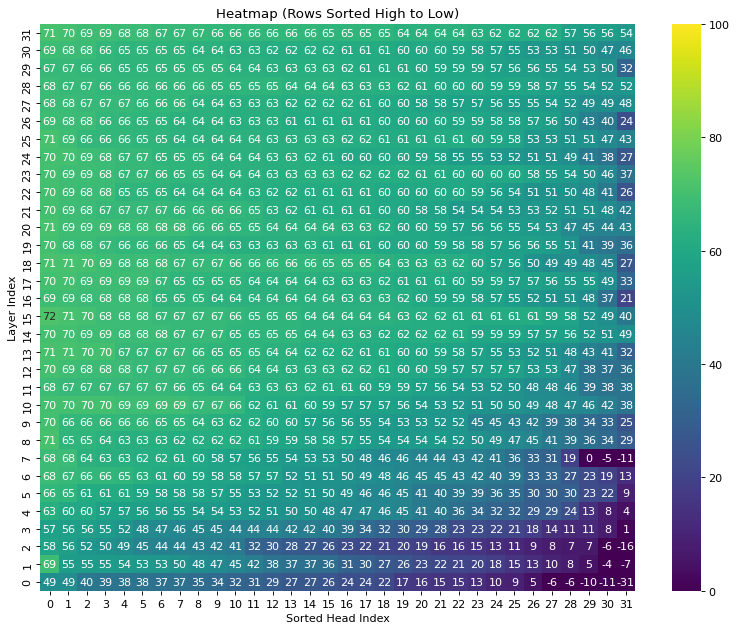

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/statements_border_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

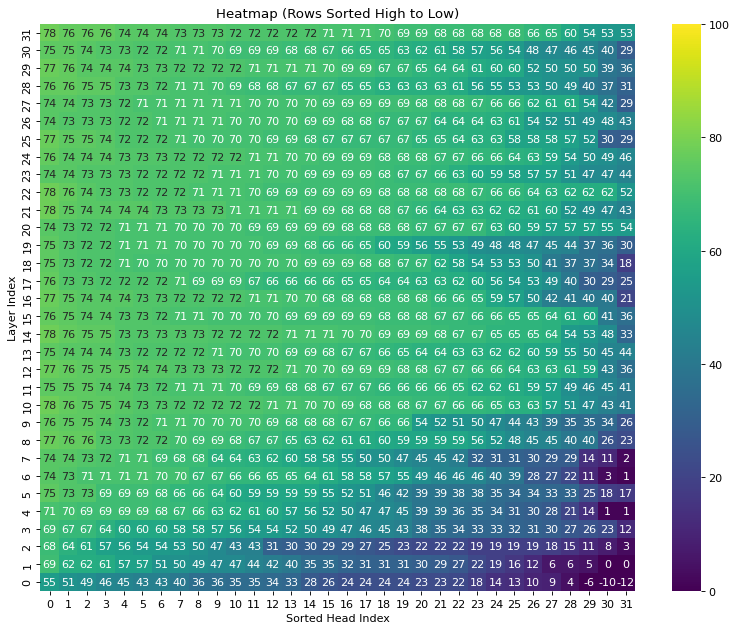

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/statements_transgender_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

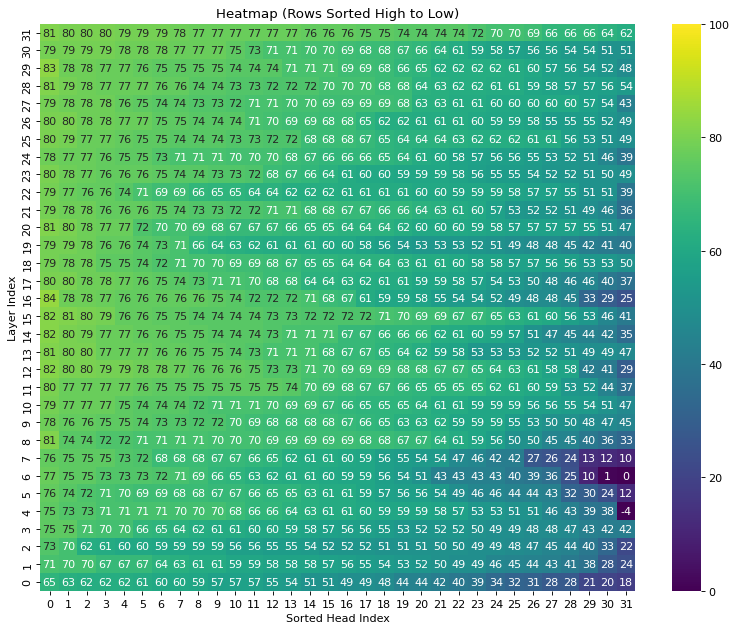

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/statements_ukraine_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

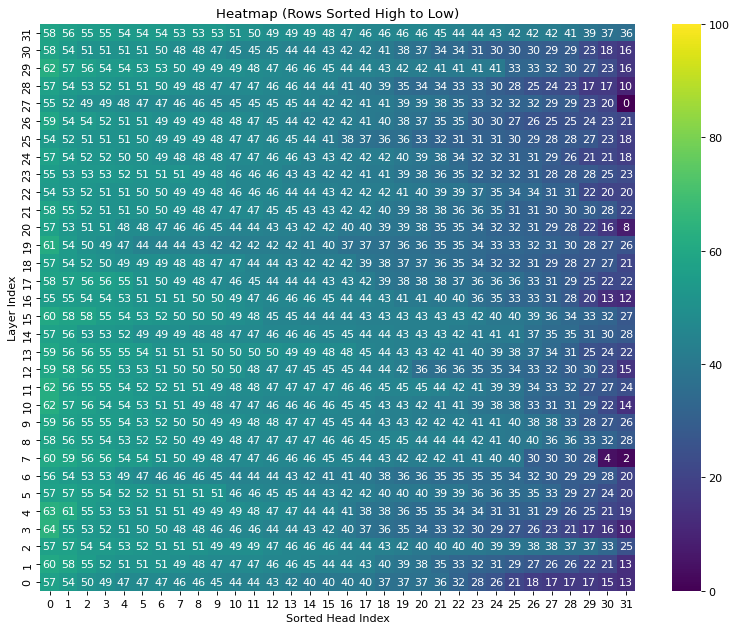

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/statements_israel_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

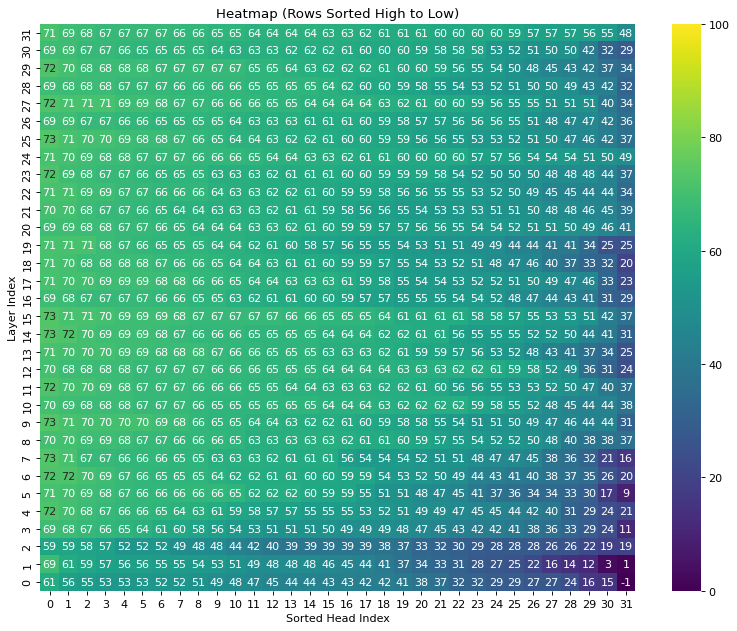

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/statements_gaza_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

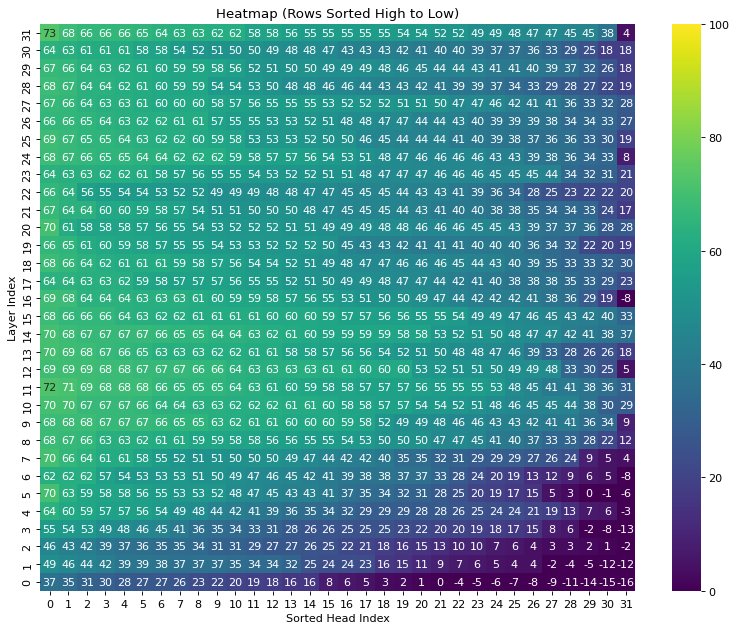

In [25]:
domains = prompts_statements_v2["domain"].unique()

model_path = MODELS[0]

for d in domains:
    d_short = d.split(" ")[0].lower()
    subset = prompts_statements_v2[prompts_statements_v2["domain"] == d]
    probe_heads(
        model_path=model_path,
        prompts=subset["prompt"].tolist(),
        labels=subset["label"].tolist(),
        prefix=f"statements_{d_short}",
        device=device,
        alpha=1.0,
        n_splits=2,
        seed=42,
        data_dir="results",
        figsize=(10, 8),
        dpi=80,
        cmap='viridis',
        vmin=0,
        vmax=100
    )


In [42]:
import os, glob, pickle
import numpy as np

RESULTS_DIR = "results/llama-2-7b-chat-hf"
PERF_PATTERN  = "statements_*_performance.pkl"
RIDGE_PATTERN = "statements_*_ridge.pkl"
POL_REF_PATH  = os.path.join(RESULTS_DIR, "politician_ridge.pkl")
THRESH = 0.70

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# -------------------- load perfs, find (layer, head) that pass all --------------------
perf_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, PERF_PATTERN)))
if not perf_paths:
    raise FileNotFoundError(f"No files matched {PERF_PATTERN} in {RESULTS_DIR}")

perf_names = [
    os.path.basename(p).replace("statements_", "").replace("_performance.pkl", "")
    for p in perf_paths
]

perf_arrs = []
for p in perf_paths:
    a = np.asarray(load_pkl(p))
    if a.ndim != 2:
        raise ValueError(f"{p}: expected [layers, heads], got {a.shape}")
    perf_arrs.append(a)

L, H = perf_arrs[0].shape
for p, a in zip(perf_paths, perf_arrs):
    if a.shape != (L, H):
        raise ValueError(f"Shape mismatch: {p} has {a.shape}, expected {(L, H)}")

stack = np.stack(perf_arrs, axis=0)           # [n_tasks, L, H]
ok = np.all(stack > THRESH, axis=0)           # [L, H]
layers, heads = np.where(ok)
passing = list(zip(map(int, layers), map(int, heads)))

print(f"Tasks: {perf_names}")
print(f"Passing (layer, head) pairs across ALL statement tasks with r^2 > {THRESH}: {len(passing)}")
print("First few passing:", passing[:20])

# -------------------- load statement ridge models --------------------
ridge_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, RIDGE_PATTERN)))
if not ridge_paths:
    raise FileNotFoundError(f"No files matched {RIDGE_PATTERN} in {RESULTS_DIR}")

ridge_by_task = {}
for p in ridge_paths:
    task = os.path.basename(p).replace("statements_", "").replace("_ridge.pkl", "")
    ridge_by_task[task] = load_pkl(p)

# keep only tasks where we have both perf and ridge
tasks = [t for t in perf_names if t in ridge_by_task]
missing = [t for t in perf_names if t not in ridge_by_task]
if missing:
    print("WARNING: missing ridge pkls for:", missing)

if not tasks:
    raise RuntimeError("No overlapping tasks between performance and ridge pkls.")

# -------------------- load politician reference ridge --------------------
if not os.path.exists(POL_REF_PATH):
    raise FileNotFoundError(f"Reference ridge not found: {POL_REF_PATH}")

politician_ridge = load_pkl(POL_REF_PATH)

# -------------------- helpers --------------------
def get_coef_intercept(model):
    coef = getattr(model, "coef_", None)
    intercept = getattr(model, "intercept_", None)
    if coef is None:
        raise AttributeError("Model has no coef_ attribute; adjust get_coef_intercept() for your object.")
    coef = np.asarray(coef).ravel()
    if intercept is None:
        intercept = 0.0
    intercept = float(np.asarray(intercept).ravel()[0]) if np.asarray(intercept).size else float(intercept)
    return coef, intercept

def compare_params(coef_a, b_a, coef_b, b_b):
    denom = (np.linalg.norm(coef_a) * np.linalg.norm(coef_b))
    cos = float(np.dot(coef_a, coef_b) / denom) if denom > 0 else np.nan
    l2 = float(np.linalg.norm(coef_a - coef_b))
    if coef_a.size == coef_b.size and coef_a.size > 1:
        corr = float(np.corrcoef(coef_a, coef_b)[0, 1])
    else:
        corr = np.nan
    db = float(b_a - b_b)
    return cos, corr, l2, db

def ridge_at(ridge_obj, layer, head):
    # expected ridge[layer][head] -> sklearn Ridge
    return ridge_obj[layer][head]

# -------------------- compare all statement tasks to politician ridge --------------------
print(f"\nComparing ridge parameters for passing heads against politician reference: {POL_REF_PATH}")

# pre-extract politician params for passing heads
pol_params = {}
for (l, h) in passing:
    m = ridge_at(politician_ridge, l, h)
    pol_params[(l, h)] = get_coef_intercept(m)

# For each passing head, compare politician params to every statement task
for (l, h) in passing[:20]:  # limit print; remove [:20] to print all
    coef_pol, b_pol = pol_params[(l, h)]
    print(f"\n(layer={l}, head={h})  dim={coef_pol.size}")
    for t in tasks:
        ridge = ridge_by_task[t]
        coef_t, b_t = get_coef_intercept(ridge_at(ridge, l, h))
        cos, corr, l2, db = compare_params(coef_pol, b_pol, coef_t, b_t)
        print(f"  pol vs {t:14s}  cos={cos: .3f}  corr={corr: .3f}  L2={l2: .3f}  d_intercept={db: .3f}")

# -------------------- aggregate summary --------------------
def aggregate(metric_index):
    vals = []
    for (l, h) in passing:
        coef_pol, b_pol = pol_params[(l, h)]
        for t in tasks:
            ridge = ridge_by_task[t]
            coef_t, b_t = get_coef_intercept(ridge_at(ridge, l, h))
            cos, corr, l2, db = compare_params(coef_pol, b_pol, coef_t, b_t)
            vals.append([cos, corr, l2, db][metric_index])
    arr = np.asarray(vals, dtype=float)
    return np.nanmean(arr), np.nanmedian(arr)

if passing and tasks:
    mean_cos, med_cos = aggregate(0)
    mean_corr, med_corr = aggregate(1)
    mean_l2,  med_l2  = aggregate(2)
    mean_db,  med_db  = aggregate(3)
    print("\nAggregate (across all passing heads × all statement tasks; politician as reference):")
    print(f"  cosine   mean={mean_cos:.3f}  median={med_cos:.3f}")
    print(f"  corr     mean={mean_corr:.3f} median={med_corr:.3f}")
    print(f"  L2       mean={mean_l2:.3f}   median={med_l2:.3f}")
    print(f"  d_b      mean={mean_db:.3f}   median={med_db:.3f}")


Tasks: ['abortion', 'border', 'transgender']
Passing (layer, head) pairs across ALL statement tasks with r^2 > 0.7: 19
First few passing: [(10, 7), (10, 8), (10, 11), (12, 0), (13, 13), (13, 22), (13, 31), (14, 27), (14, 31), (15, 30), (17, 21), (18, 4), (18, 6), (19, 20), (23, 3), (24, 14), (25, 12), (31, 6), (31, 15)]

Comparing ridge parameters for passing heads against politician reference: results/llama-2-7b-chat-hf/politician_ridge.pkl

(layer=10, head=7)  dim=128
  pol vs abortion        cos= 0.142  corr= 0.147  L2= 1.657  d_intercept= 0.000
  pol vs border          cos= 0.126  corr= 0.129  L2= 1.763  d_intercept= 0.000
  pol vs transgender     cos= 0.089  corr= 0.089  L2= 1.898  d_intercept= 0.000

(layer=10, head=8)  dim=128
  pol vs abortion        cos=-0.019  corr=-0.019  L2= 3.059  d_intercept= 0.000
  pol vs border          cos=-0.027  corr=-0.027  L2= 3.102  d_intercept= 0.000
  pol vs transgender     cos= 0.137  corr= 0.142  L2= 2.950  d_intercept= 0.000

(layer=10, head

### Policies with Synthetic stances

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/250 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_abortion_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

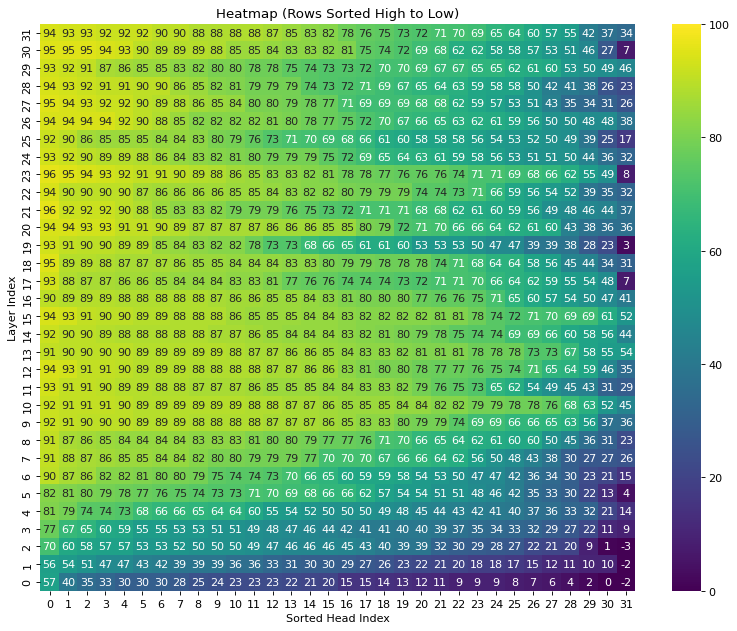

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/400 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_gender_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

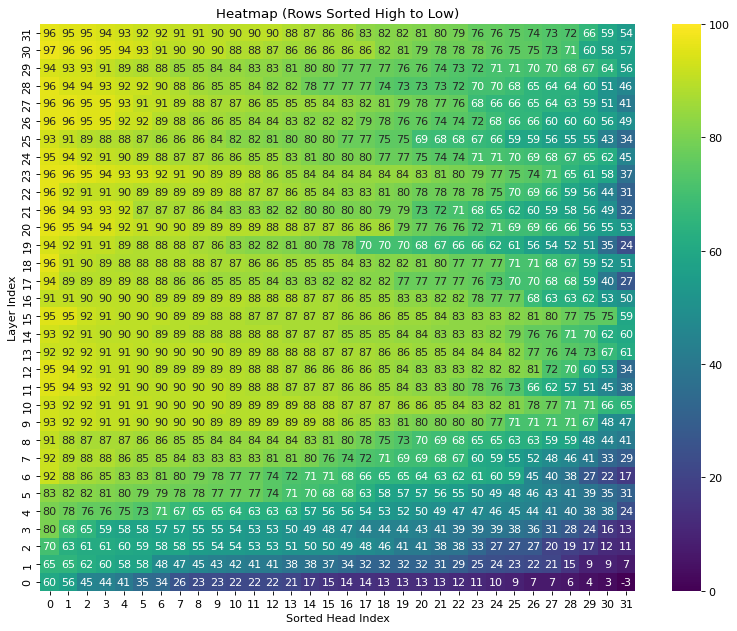

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/350 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_immigration_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

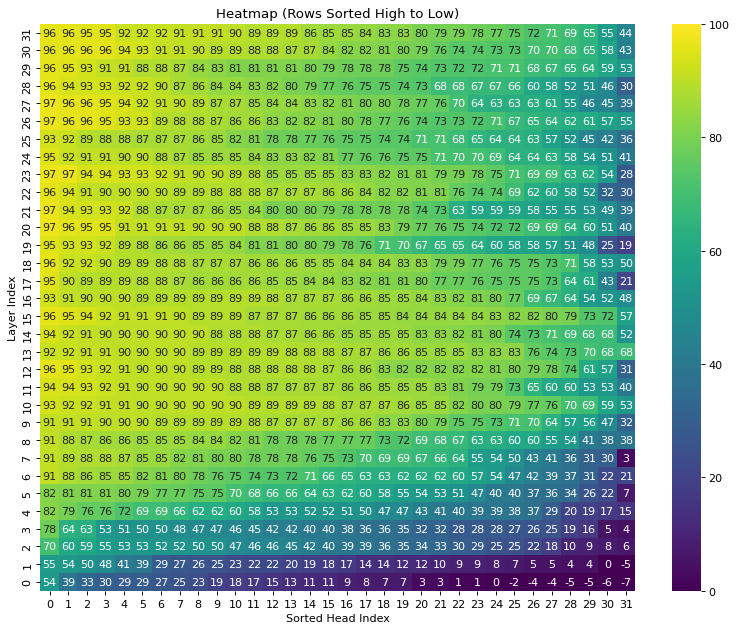

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/250 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_healthcare_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

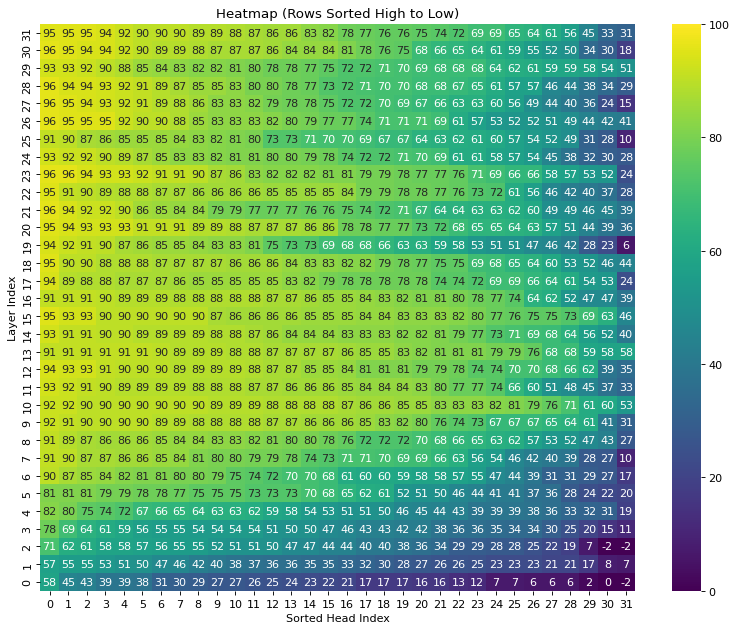

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/300 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_economy_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

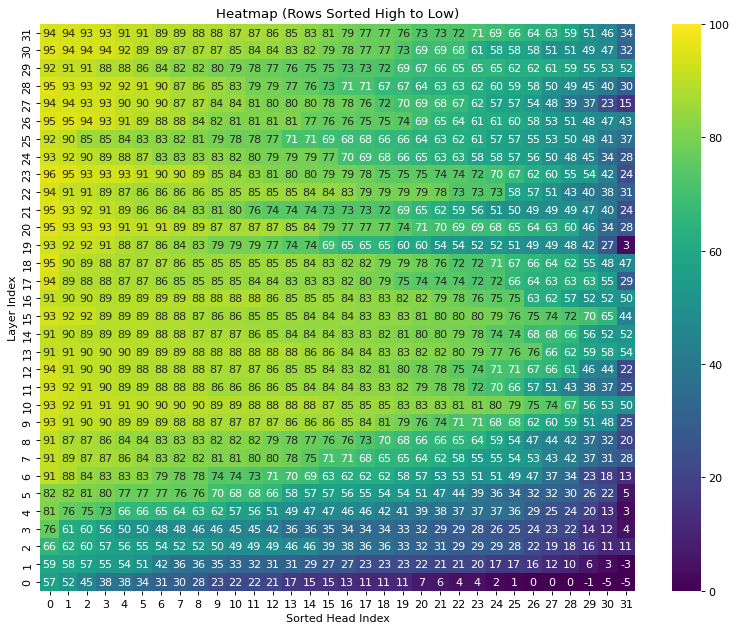

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/300 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_climate_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

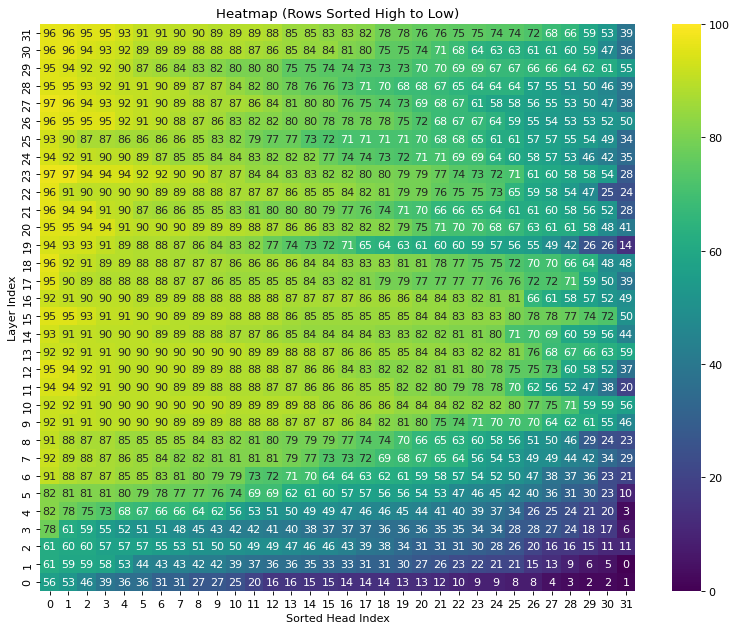

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/300 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/stances_gun_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

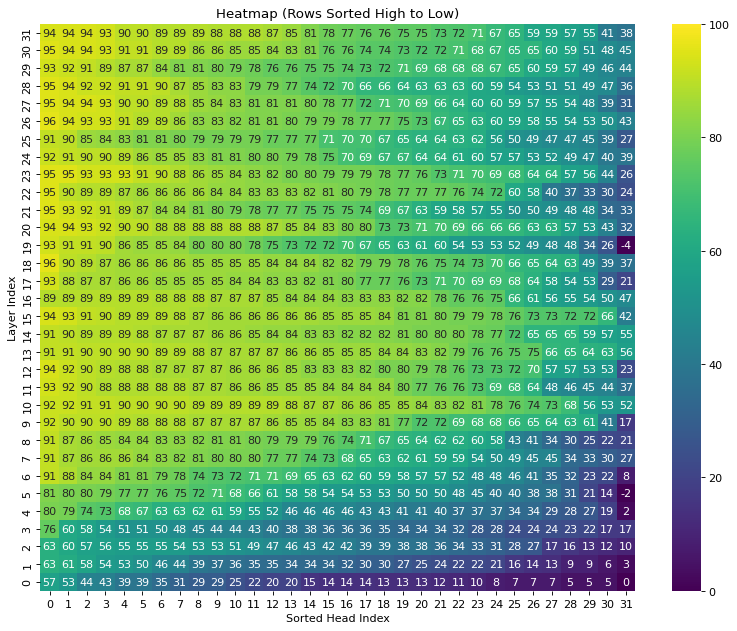

In [ ]:
domains = df_prompts_stances["domain"].unique()

model_path = MODELS[0]

for d in domains:
    d_short = d.split(" ")[0].lower()
    subset = df_prompts_stances[df_prompts_stances["domain"] == d]
    probe_heads(
        model_path=model_path,
        prompts=subset["prompt"].tolist(),
        labels=subset["label"].tolist(),
        prefix=f"stances_{d_short}",
        device=device,
        alpha=1.0,
        n_splits=2,
        seed=42,
        data_dir="results",
        figsize=(10, 8),
        dpi=80,
        cmap='viridis',
        vmin=0,
        vmax=100
    )

In [ ]:
import os, glob, pickle
import numpy as np

RESULTS_DIR = "results/llama-2-7b-chat-hf"
PERF_PATTERN  = "stances_*_performance.pkl"
RIDGE_PATTERN = "stances_*_ridge.pkl"
POL_REF_PATH  = os.path.join(RESULTS_DIR, "politician_ridge.pkl")
THRESH = 0.93

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# -------------------- load perfs, find (layer, head) that pass all --------------------
perf_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, PERF_PATTERN)))
if not perf_paths:
    raise FileNotFoundError(f"No files matched {PERF_PATTERN} in {RESULTS_DIR}")

perf_names = [
    os.path.basename(p).replace("stances_", "").replace("_performance.pkl", "")
    for p in perf_paths
]

perf_arrs = []
for p in perf_paths:
    a = np.asarray(load_pkl(p))
    if a.ndim != 2:
        raise ValueError(f"{p}: expected [layers, heads], got {a.shape}")
    perf_arrs.append(a)

L, H = perf_arrs[0].shape
for p, a in zip(perf_paths, perf_arrs):
    if a.shape != (L, H):
        raise ValueError(f"Shape mismatch: {p} has {a.shape}, expected {(L, H)}")

stack = np.stack(perf_arrs, axis=0)           # [n_tasks, L, H]
ok = np.all(stack > THRESH, axis=0)           # [L, H]
layers, heads = np.where(ok)
passing = list(zip(map(int, layers), map(int, heads)))

print(f"Tasks: {perf_names}")
print(f"Passing (layer, head) pairs across ALL statement tasks with r^2 > {THRESH}: {len(passing)}")
print("First few passing:", passing[:20])

# -------------------- load statement ridge models --------------------
ridge_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, RIDGE_PATTERN)))
if not ridge_paths:
    raise FileNotFoundError(f"No files matched {RIDGE_PATTERN} in {RESULTS_DIR}")

ridge_by_task = {}
for p in ridge_paths:
    task = os.path.basename(p).replace("stances_", "").replace("_ridge.pkl", "")
    ridge_by_task[task] = load_pkl(p)

# keep only tasks where we have both perf and ridge
tasks = [t for t in perf_names if t in ridge_by_task]
missing = [t for t in perf_names if t not in ridge_by_task]
if missing:
    print("WARNING: missing ridge pkls for:", missing)

if not tasks:
    raise RuntimeError("No overlapping tasks between performance and ridge pkls.")

# -------------------- load politician reference ridge --------------------
if not os.path.exists(POL_REF_PATH):
    raise FileNotFoundError(f"Reference ridge not found: {POL_REF_PATH}")

politician_ridge = load_pkl(POL_REF_PATH)

# -------------------- helpers --------------------
def get_coef_intercept(model):
    coef = getattr(model, "coef_", None)
    intercept = getattr(model, "intercept_", None)
    if coef is None:
        raise AttributeError("Model has no coef_ attribute; adjust get_coef_intercept() for your object.")
    coef = np.asarray(coef).ravel()
    if intercept is None:
        intercept = 0.0
    intercept = float(np.asarray(intercept).ravel()[0]) if np.asarray(intercept).size else float(intercept)
    return coef, intercept

def compare_params(coef_a, b_a, coef_b, b_b):
    denom = (np.linalg.norm(coef_a) * np.linalg.norm(coef_b))
    cos = float(np.dot(coef_a, coef_b) / denom) if denom > 0 else np.nan
    l2 = float(np.linalg.norm(coef_a - coef_b))
    if coef_a.size == coef_b.size and coef_a.size > 1:
        corr = float(np.corrcoef(coef_a, coef_b)[0, 1])
    else:
        corr = np.nan
    db = float(b_a - b_b)
    return cos, corr, l2, db

def ridge_at(ridge_obj, layer, head):
    # expected ridge[layer][head] -> sklearn Ridge
    return ridge_obj[layer][head]

# -------------------- compare all statement tasks to politician ridge --------------------
print(f"\nComparing ridge parameters for passing heads against politician reference: {POL_REF_PATH}")

# pre-extract politician params for passing heads
pol_params = {}
for (l, h) in passing:
    m = ridge_at(politician_ridge, l, h)
    pol_params[(l, h)] = get_coef_intercept(m)

# For each passing head, compare politician params to every statement task
for (l, h) in passing[:20]:  # limit print; remove [:20] to print all
    coef_pol, b_pol = pol_params[(l, h)]
    print(f"\n(layer={l}, head={h})  dim={coef_pol.size}")
    for t in tasks:
        ridge = ridge_by_task[t]
        coef_t, b_t = get_coef_intercept(ridge_at(ridge, l, h))
        cos, corr, l2, db = compare_params(coef_pol, b_pol, coef_t, b_t)
        print(f"  pol vs {t:14s}  cos={cos: .3f}  corr={corr: .3f}  L2={l2: .3f}  d_intercept={db: .3f}")

# -------------------- aggregate summary --------------------
def aggregate(metric_index):
    vals = []
    for (l, h) in passing:
        coef_pol, b_pol = pol_params[(l, h)]
        for t in tasks:
            ridge = ridge_by_task[t]
            coef_t, b_t = get_coef_intercept(ridge_at(ridge, l, h))
            cos, corr, l2, db = compare_params(coef_pol, b_pol, coef_t, b_t)
            vals.append([cos, corr, l2, db][metric_index])
    arr = np.asarray(vals, dtype=float)
    return np.nanmean(arr), np.nanmedian(arr)

if passing and tasks:
    mean_cos, med_cos = aggregate(0)
    mean_corr, med_corr = aggregate(1)
    mean_l2,  med_l2  = aggregate(2)
    mean_db,  med_db  = aggregate(3)
    print("\nAggregate (across all passing heads × all statement tasks; politician as reference):")
    print(f"  cosine   mean={mean_cos:.3f}  median={med_cos:.3f}")
    print(f"  corr     mean={mean_corr:.3f} median={med_corr:.3f}")
    print(f"  L2       mean={mean_l2:.3f}   median={med_l2:.3f}")
    print(f"  d_b      mean={mean_db:.3f}   median={med_db:.3f}")

Tasks: ['abortion', 'climate', 'economy', 'gender', 'gun', 'healthcare', 'immigration']
Passing (layer, head) pairs across ALL statement tasks with r^2 > 0.93: 30
First few passing: [(11, 6), (12, 5), (15, 11), (17, 21), (18, 23), (19, 5), (20, 9), (20, 13), (20, 15), (21, 6), (22, 10), (23, 1), (23, 2), (23, 6), (23, 14), (26, 4), (26, 14), (26, 19), (26, 30), (27, 2)]

Comparing ridge parameters for passing heads against politician reference: results/llama-2-7b-chat-hf/politician_ridge.pkl

(layer=11, head=6)  dim=128
  pol vs abortion        cos=-0.067  corr=-0.054  L2= 3.024  d_intercept= 0.000
  pol vs climate         cos= 0.019  corr= 0.035  L2= 2.785  d_intercept= 0.000
  pol vs economy         cos=-0.050  corr=-0.036  L2= 2.891  d_intercept= 0.000
  pol vs gender          cos= 0.047  corr= 0.068  L2= 3.041  d_intercept= 0.000
  pol vs gun             cos= 0.015  corr= 0.035  L2= 2.874  d_intercept= 0.000
  pol vs healthcare      cos=-0.059  corr=-0.046  L2= 2.951  d_intercept= 

In [4]:
import os, glob, pickle
import numpy as np
import pandas as pd


RESULTS_DIR = "results/llama-2-7b-chat-hf"
RIDGE_PATTERN = "stances_*_ridge.pkl"
POL_REF_PATH  = os.path.join(RESULTS_DIR, "politician_ridge.pkl")
OUT_CSV       = os.path.join(RESULTS_DIR, "mean_statement_vs_politician_corr.csv")

# If True, only include (layer, head) pairs that exist in ALL tasks (intersection).
# If False, include any (layer, head) with at least MIN_TASKS coverage.
REQUIRE_ALL_TASKS = True
MIN_TASKS = 1  # used only if REQUIRE_ALL_TASKS is False


def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def get_coef_intercept(model):
    coef = getattr(model, "coef_", None)
    intercept = getattr(model, "intercept_", None)
    if coef is None:
        raise AttributeError("Model has no coef_ attribute.")
    coef = np.asarray(coef).ravel().astype(float)
    if intercept is None:
        intercept = 0.0
    intercept_arr = np.asarray(intercept).ravel()
    intercept = float(intercept_arr[0]) if intercept_arr.size else float(intercept)
    return coef, intercept


def ridge_at(ridge_obj, layer, head):
    return ridge_obj[layer][head]


def safe_corr(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    if a.size != b.size or a.size < 2:
        return np.nan
    sa = np.std(a)
    sb = np.std(b)
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def safe_cos(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return float(np.dot(a, b) / denom)


def safe_l2(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    if a.size != b.size:
        return np.nan
    return float(np.linalg.norm(a - b))


def main():
    ridge_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, RIDGE_PATTERN)))
    if not ridge_paths:
        raise FileNotFoundError(f"No files matched {RIDGE_PATTERN} in {RESULTS_DIR}")

    if not os.path.exists(POL_REF_PATH):
        raise FileNotFoundError(f"Reference ridge not found: {POL_REF_PATH}")

    # Load statement ridges
    ridge_by_task = {}
    for p in ridge_paths:
        task = os.path.basename(p).replace("stances_", "").replace("_ridge.pkl", "")
        ridge_by_task[task] = load_pkl(p)

    tasks = sorted(ridge_by_task.keys())
    print(f"Loaded {len(tasks)} statement ridge tasks.")
    print("Tasks:", tasks)

    # Load politician ridge
    politician_ridge = load_pkl(POL_REF_PATH)

    # Determine layer/head grid from politician ridge (most reliable anchor)
    # politician_ridge is expected to be [L][H] list-like.
    L = len(politician_ridge)
    H = len(politician_ridge[0]) if L else 0
    if L == 0 or H == 0:
        raise ValueError("Politician ridge appears empty or malformed.")

    # For each (layer, head), collect statement params across tasks
    rows = []
    included = 0

    for l in range(L):
        for h in range(H):
            # get politician params; if missing, skip
            try:
                coef_pol, b_pol = get_coef_intercept(ridge_at(politician_ridge, l, h))
            except Exception:
                continue

            coefs = []
            bs = []
            present_tasks = 0

            for t in tasks:
                ridge_obj = ridge_by_task[t]
                try:
                    coef_t, b_t = get_coef_intercept(ridge_at(ridge_obj, l, h))
                except Exception:
                    continue
                # Guard against dimension mismatch across tasks
                if coef_t.size != coef_pol.size:
                    continue
                coefs.append(coef_t)
                bs.append(b_t)
                present_tasks += 1

            if REQUIRE_ALL_TASKS:
                if present_tasks != len(tasks):
                    continue
            else:
                if present_tasks < MIN_TASKS:
                    continue

            if not coefs:
                continue

            coef_mean = np.mean(np.stack(coefs, axis=0), axis=0)
            b_mean = float(np.mean(np.asarray(bs, dtype=float)))

            corr = safe_corr(coef_mean, coef_pol)
            cos  = safe_cos(coef_mean, coef_pol)
            l2   = safe_l2(coef_mean, coef_pol)
            db   = float(b_mean - b_pol)

            rows.append({
                "layer": l,
                "head": h,
                "tasks_used": present_tasks,
                "dim": int(coef_pol.size),
                "corr_coef": corr,
                "cosine": cos,
                "l2": l2,
                "b_mean": b_mean,
                "b_politician": b_pol,
                "d_intercept": db,
            })
            included += 1

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(
            "No heads included. If REQUIRE_ALL_TASKS=True, try setting it to False "
            "or lowering MIN_TASKS."
        )

    df.to_csv(OUT_CSV, index=False)
    print(f"\nSaved {len(df)} rows to: {OUT_CSV}")

    # Print top correlations (ignoring NaNs)
    df_rank = df.dropna(subset=["corr_coef"]).sort_values("corr_coef", ascending=False)
    print("\nTop 20 (layer, head) by corr(coef_mean, coef_politician):")
    for r in df_rank.head(50).itertuples():
        print(
            f"  (l={int(r.layer):2d}, h={int(r.head):2d}) "
            f"corr={r.corr_coef: .3f} cos={r.cosine: .3f} "
            f"L2={r.l2: .3f} tasks={int(r.tasks_used)} dim={int(r.dim)}"
        )

    # Quick aggregate stats
    print("\nAggregate across included heads:")
    print(f"  corr mean={np.nanmean(df['corr_coef']):.3f} median={np.nanmedian(df['corr_coef']):.3f}")
    print(f"  cos  mean={np.nanmean(df['cosine']):.3f}   median={np.nanmedian(df['cosine']):.3f}")
    print(f"  L2   mean={np.nanmean(df['l2']):.3f}      median={np.nanmedian(df['l2']):.3f}")
    print(f"  d_b  mean={np.nanmean(df['d_intercept']):.3f} median={np.nanmedian(df['d_intercept']):.3f}")


if __name__ == "__main__":
    main()

Loaded 7 statement ridge tasks.
Tasks: ['abortion', 'climate', 'economy', 'gender', 'gun', 'healthcare', 'immigration']

Saved 1024 rows to: results/llama-2-7b-chat-hf/mean_statement_vs_politician_corr.csv

Top 20 (layer, head) by corr(coef_mean, coef_politician):
  (l= 0, h=11) corr= 0.882 cos= 0.882 L2= 0.211 tasks=7 dim=128
  (l= 3, h= 4) corr= 0.820 cos= 0.816 L2= 0.221 tasks=7 dim=128
  (l= 0, h=27) corr= 0.801 cos= 0.802 L2= 0.179 tasks=7 dim=128
  (l= 0, h= 5) corr= 0.768 cos= 0.769 L2= 0.234 tasks=7 dim=128
  (l= 0, h=24) corr= 0.727 cos= 0.727 L2= 0.222 tasks=7 dim=128
  (l= 0, h=19) corr= 0.698 cos= 0.693 L2= 0.236 tasks=7 dim=128
  (l= 2, h=13) corr= 0.685 cos= 0.678 L2= 0.264 tasks=7 dim=128
  (l=12, h= 2) corr= 0.661 cos= 0.660 L2= 0.260 tasks=7 dim=128
  (l= 0, h=22) corr= 0.654 cos= 0.658 L2= 0.287 tasks=7 dim=128
  (l= 1, h=30) corr= 0.637 cos= 0.636 L2= 0.308 tasks=7 dim=128
  (l= 6, h=16) corr= 0.631 cos= 0.627 L2= 0.203 tasks=7 dim=128
  (l= 2, h= 2) corr= 0.627 cos=

### Policies with Integrated Stances

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_abortion_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

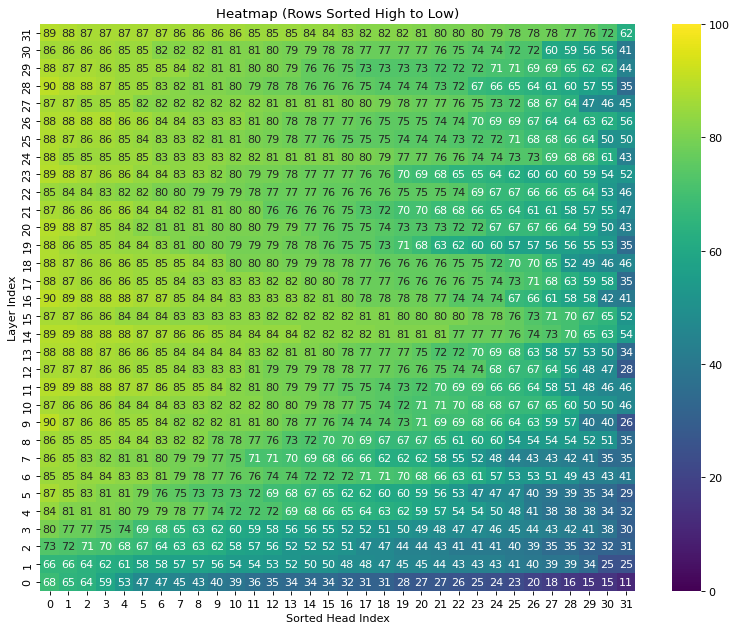

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/800 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_gender_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

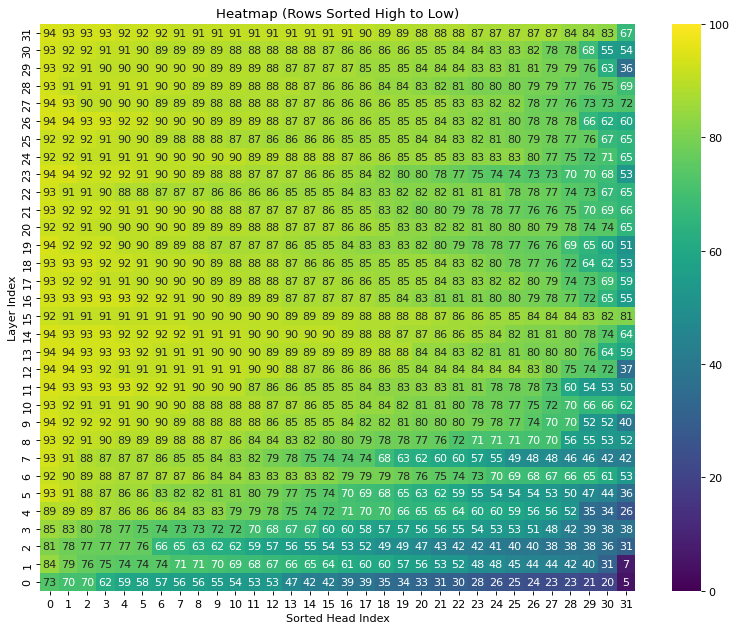

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/700 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_immigration_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

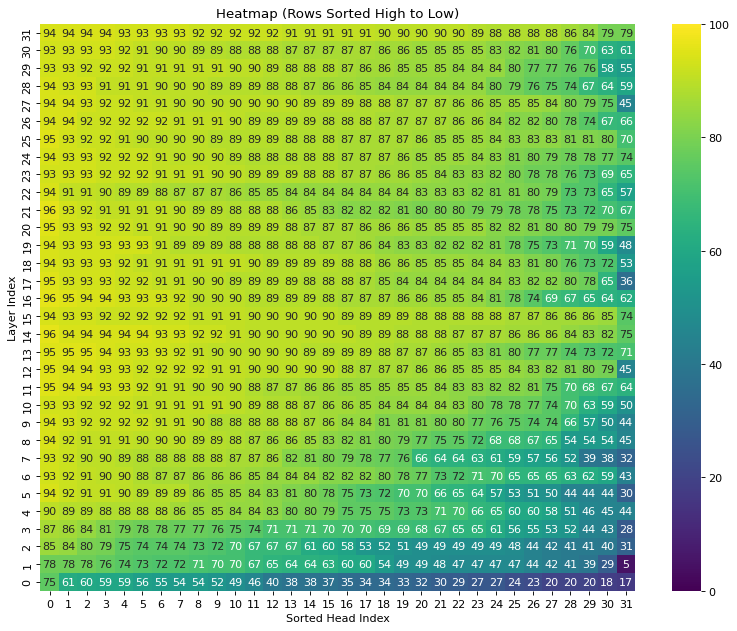

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_healthcare_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

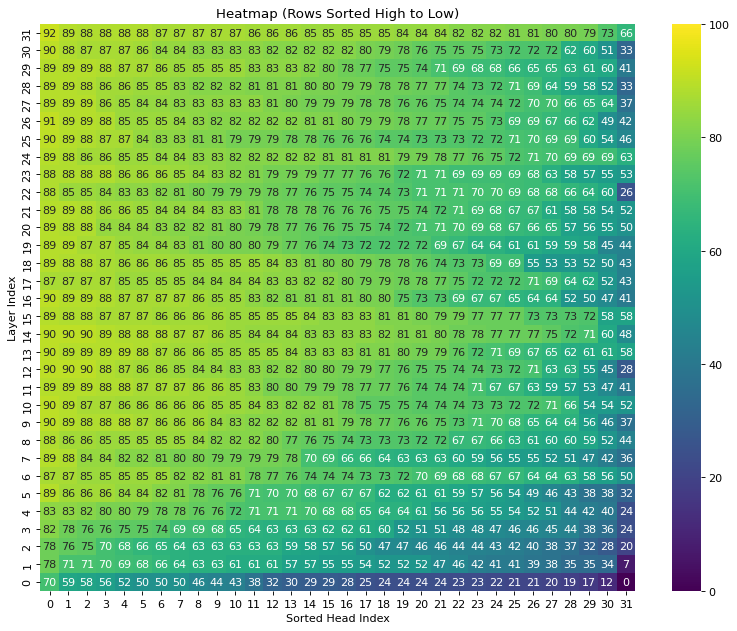

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/600 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_economic_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

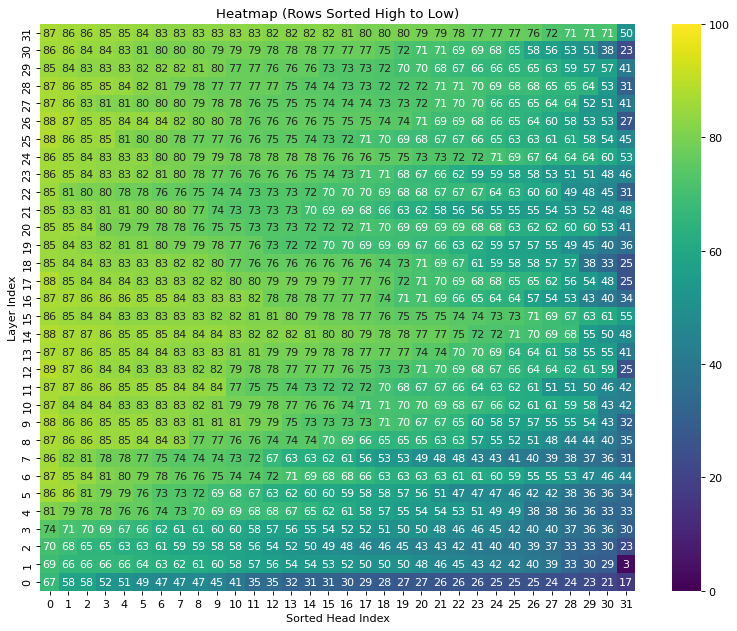

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/600 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_climate_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

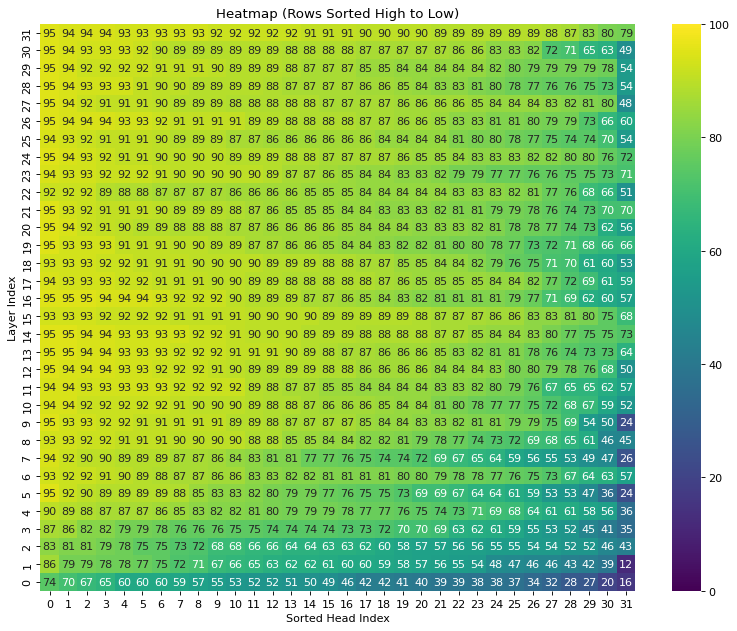

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/600 [00:00<?, ?it/s]

Saved features and labels to results/llama-2-7b-chat-hf/integrated_gun_features.pkl


Layers:   0%|          | 0/32 [00:00<?, ?it/s]

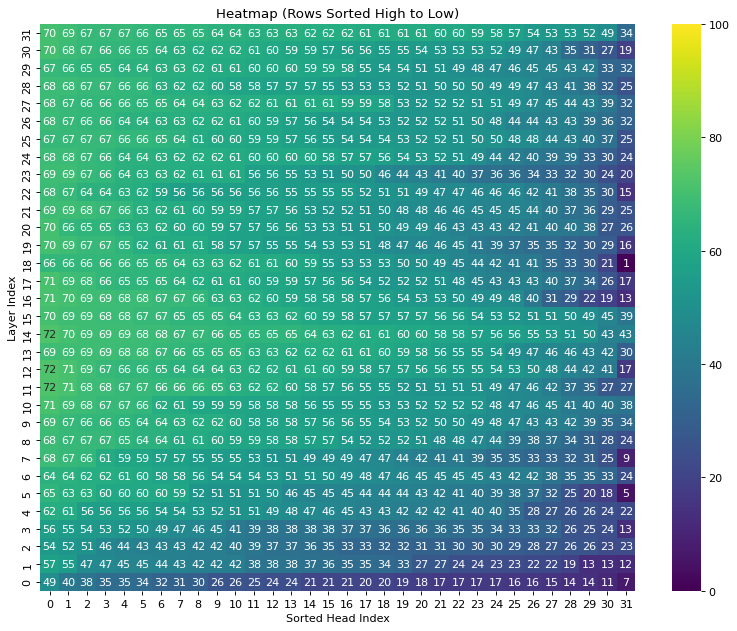

In [47]:
domains = df_statements_integrated["domain"].unique()

model_path = MODELS[0]

for d in domains:
    d_short = d.replace(",", "").split(" ")[0].lower()
    subset = df_statements_integrated[df_statements_integrated["domain"] == d]
    probe_heads(
        model_path=model_path,
        prompts=subset["prompt"].tolist(),
        labels=subset["label"].tolist(),
        prefix=f"integrated_{d_short}",
        device=device,
        alpha=1.0,
        n_splits=2,
        seed=42,
        data_dir="results",
        figsize=(10, 8),
        dpi=80,
        cmap='viridis',
        vmin=0,
        vmax=100
    )

In [40]:
import os, glob, pickle
import numpy as np

RESULTS_DIR   = "results/llama-2-7b-chat-hf"
PREFIX = "integrated"
PERF_PATTERN  = f"{PREFIX}_*_performance.pkl"
RIDGE_PATTERN = f"{PREFIX}_*_ridge.pkl"
POL_REF_PATH  = os.path.join(RESULTS_DIR, "politician_ridge.pkl")

TOP_K = 16

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def topk_heads(perf_2d: np.ndarray, k: int):
    """
    perf_2d: [L, H] performance values (higher is better)
    Returns a set of (layer, head) for the global top-k entries.
    """
    L, H = perf_2d.shape
    k = int(min(k, L * H))
    flat = perf_2d.reshape(-1)

    # handle NaNs by treating them as -inf so they never enter top-k
    flat_safe = np.where(np.isnan(flat), -np.inf, flat)

    # argpartition gives top-k unsorted indices; then sort within top-k
    idx_top = np.argpartition(flat_safe, -k)[-k:]
    idx_top = idx_top[np.argsort(flat_safe[idx_top])[::-1]]

    layers = (idx_top // H).astype(int)
    heads  = (idx_top %  H).astype(int)
    return set(zip(layers.tolist(), heads.tolist()))

# -------------------- load perfs, take intersection of top-k across all variants/tasks --------------------
perf_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, PERF_PATTERN)))

perf_names = [
    os.path.basename(p).replace(f"{PREFIX}_", "").replace("_performance.pkl", "")
    for p in perf_paths
]

perf_arrs = []
for p in perf_paths:
    a = np.asarray(load_pkl(p))
    perf_arrs.append(a)

L, H = perf_arrs[0].shape
topk_sets = []
for name, arr in zip(perf_names, perf_arrs):
    s = topk_heads(arr, TOP_K)
    topk_sets.append(s)
    best_val = np.nanmax(arr)
    print(f"{name:20s} top-{TOP_K:<5d} set size={len(s):<6d} best={best_val:.4f}")

# intersection across ALL variants/tasks
if not topk_sets:
    raise RuntimeError("No performance arrays loaded.")

intersection = set.intersection(*topk_sets)
passing = sorted(intersection)  # list of (layer, head)

print("\nTasks:", perf_names)
print(f"Intersection size (common to ALL top-{TOP_K} sets): {len(passing)}")
print("First few intersecting (layer, head):", passing[:20])

# -------------------- load statement ridge models --------------------
ridge_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, RIDGE_PATTERN)))
if not ridge_paths:
    raise FileNotFoundError(f"No files matched {RIDGE_PATTERN} in {RESULTS_DIR}")

ridge_by_task = {}
for p in ridge_paths:
    task = os.path.basename(p).replace(f"{PREFIX}_", "").replace("_ridge.pkl", "")
    ridge_by_task[task] = load_pkl(p)

# keep only tasks where we have both perf and ridge
tasks = [t for t in perf_names if t in ridge_by_task]
missing = [t for t in perf_names if t not in ridge_by_task]
if missing:
    print("WARNING: missing ridge pkls for:", missing)

if not tasks:
    raise RuntimeError("No overlapping tasks between performance and ridge pkls.")

# -------------------- load politician reference ridge --------------------
politician_ridge = load_pkl(POL_REF_PATH)

# -------------------- helpers --------------------
def get_coef_intercept(model):
    coef = getattr(model, "coef_", None)
    intercept = getattr(model, "intercept_", None)
    if coef is None:
        raise AttributeError("Model has no coef_ attribute; adjust get_coef_intercept() for your object.")
    coef = np.asarray(coef).ravel()
    if intercept is None:
        intercept = 0.0
    intercept = float(np.asarray(intercept).ravel()[0]) if np.asarray(intercept).size else float(intercept)
    return coef, intercept

def compare_params(coef_a, b_a, coef_b, b_b):
    denom = (np.linalg.norm(coef_a) * np.linalg.norm(coef_b))
    cos = float(np.dot(coef_a, coef_b) / denom) if denom > 0 else np.nan
    l2  = float(np.linalg.norm(coef_a - coef_b))
    if coef_a.size == coef_b.size and coef_a.size > 1:
        corr = float(np.corrcoef(coef_a, coef_b)[0, 1])
    else:
        corr = np.nan
    db = float(b_a - b_b)
    return cos, corr, l2, db

def ridge_at(ridge_obj, layer, head):
    # expected ridge[layer][head] -> sklearn Ridge (or similar)
    return ridge_obj[layer][head]

# -------------------- compare all statement tasks to politician ridge --------------------
print(f"\nComparing ridge parameters for intersecting heads against politician reference: {POL_REF_PATH}")

# pre-extract politician params for intersecting heads
pol_params = {}
for (l, h) in passing:
    m = ridge_at(politician_ridge, l, h)
    pol_params[(l, h)] = get_coef_intercept(m)

# For each intersecting head, compare politician params to every statement task
PRINT_LIMIT = 20  # set None to print all
to_print = passing if PRINT_LIMIT is None else passing[:PRINT_LIMIT]

for (l, h) in to_print:
    coef_pol, b_pol = pol_params[(l, h)]
    print(f"\n(layer={l}, head={h})  dim={coef_pol.size}")
    for t in tasks:
        ridge = ridge_by_task[t]
        coef_t, b_t = get_coef_intercept(ridge_at(ridge, l, h))
        cos, corr, l2, db = compare_params(coef_pol, b_pol, coef_t, b_t)
        print(f"  pol vs {t:14s}  cos={cos: .3f}  corr={corr: .3f}  L2={l2: .3f}  d_intercept={db: .3f}")

# -------------------- aggregate summary --------------------
def aggregate(metric_index):
    vals = []
    for (l, h) in passing:
        coef_pol, b_pol = pol_params[(l, h)]
        for t in tasks:
            ridge = ridge_by_task[t]
            coef_t, b_t = get_coef_intercept(ridge_at(ridge, l, h))
            cos, corr, l2, db = compare_params(coef_pol, b_pol, coef_t, b_t)
            vals.append([cos, corr, l2, db][metric_index])
    arr = np.asarray(vals, dtype=float)
    return np.nanmean(arr), np.nanmedian(arr)

if passing and tasks:
    mean_cos, med_cos = aggregate(0)
    mean_corr, med_corr = aggregate(1)
    mean_l2,  med_l2  = aggregate(2)
    mean_db,  med_db  = aggregate(3)
    print("\nAggregate (across all intersecting heads × all statement tasks; politician as reference):")
    print(f"  cosine   mean={mean_cos:.3f}  median={med_cos:.3f}")
    print(f"  corr     mean={mean_corr:.3f}  median={med_corr:.3f}")
    print(f"  L2       mean={mean_l2:.3f}   median={med_l2:.3f}")
    print(f"  d_b      mean={mean_db:.3f}   median={med_db:.3f}")

abortion             top-16    set size=16     best=0.9036
climate              top-16    set size=16     best=0.9583
economic             top-16    set size=16     best=0.8916
gender               top-16    set size=16     best=0.9484
gun                  top-16    set size=16     best=0.7257
healthcare           top-16    set size=16     best=0.9248
immigration          top-16    set size=16     best=0.9607

Tasks: ['abortion', 'climate', 'economic', 'gender', 'gun', 'healthcare', 'immigration']
Intersection size (common to ALL top-16 sets): 0
First few intersecting (layer, head): []

Comparing ridge parameters for intersecting heads against politician reference: results/llama-2-7b-chat-hf/politician_ridge.pkl


In [45]:
# ---- add politician performance + overlaps ----
# You need a performance pkl for politician, shaped [L,H].
# Set this to wherever you saved it.
POL_PERF_PATH = os.path.join(RESULTS_DIR, "politician_performance.pkl")

if not os.path.exists(POL_PERF_PATH):
    raise FileNotFoundError(
        f"Missing politician performance file: {POL_PERF_PATH}\n"
        "Create/save a [L,H] performance array for politician heads, analogous to the other *_performance.pkl files."
    )

pol_perf = np.asarray(load_pkl(POL_PERF_PATH))
pol_topk = topk_heads(pol_perf, TOP_K)

# Option A: append politician as another row/col in the pairwise matrices
perf_names_plus = perf_names + ["politician"]
topk_sets_plus  = topk_sets  + [pol_topk]

overlap_mat, jaccard_mat = pairwise_overlaps(perf_names_plus, topk_sets_plus)

print("\nPairwise overlaps of top-K heads (counts) INCLUDING politician:")
print(" " * 18 + " ".join([f"{n[:14]:>14s}" for n in perf_names_plus]))
for i, name in enumerate(perf_names_plus):
    row = " ".join([f"{overlap_mat[i,j]:14d}" for j in range(len(perf_names_plus))])
    print(f"{name[:18]:18s}{row}")

print("\nPairwise overlaps of top-K heads (Jaccard) INCLUDING politician:")
print(" " * 18 + " ".join([f"{n[:14]:>14s}" for n in perf_names_plus]))
for i, name in enumerate(perf_names_plus):
    row = " ".join([f"{jaccard_mat[i,j]:14.3f}" for j in range(len(perf_names_plus))])
    print(f"{name[:18]:18s}{row}")

# Option B: quick readable summary: politician vs each task
print("\nPolitician overlaps with each task:")
for name, s in zip(perf_names, topk_sets):
    inter = sorted(s & pol_topk)
    uni   = s | pol_topk
    jac   = (len(inter) / len(uni)) if len(uni) else np.nan
    print(f"  politician ∩ {name:18s} = {len(inter):4d} heads   Jaccard={jac:.3f}   first few={inter[:20]}")



Pairwise overlaps of top-K heads (counts) INCLUDING politician:
                        abortion        climate       economic         gender            gun     healthcare    immigration     politician
abortion                      16              4              6              2              2              4              5              2
climate                        4             16              2              5              3              6              6              1
economic                       6              2             16              5              2              8              5              3
gender                         2              5              5             16              4              7              2              1
gun                            2              3              2              4             16              3              5              0
healthcare                     4              6              8              7              3             16

It might be because they are not head to head correlated, policy steered model might have a different ideology probing effect. And vice versa.

In [48]:
PREFIX = "integrated_gender"
model_path = MODELS[0]

tokenizer, model = load_tokenizer_and_model(model_path, device=device)
ridge_models, performance = load_ridge_models(model_path, prefix=PREFIX)
feats = load_feats(model_path, prefix=PREFIX, results_dir="./results", device=device)

coefs = compute_combined_coefs(
    feats=feats,
    k=16,
    ridge_models=ridge_models,
    performance=performance,
    device=device,
)

res = generate_with_head_intervention_gpu(
    model,
    tokenizer,
    prompts="USER: What would an average US politician say in 2019 about Abortion?\nASSISTANT: A possible statement would be: ",
    alpha=15,
    max_new_tokens=200,
    combined_coefs=coefs,
    return_features=True,
    device=device
)

res

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[{'features': array([[[[-7.7105e-04, -1.9150e-02, -1.9379e-03, ..., -1.4130e-02,
             4.4174e-03, -7.1411e-03],
           [-3.0308e-03,  1.7571e-04, -6.9847e-03, ...,  6.5613e-04,
             9.3613e-03, -1.0689e-02],
           [ 1.5459e-03, -1.0994e-02,  7.7362e-03, ...,  6.1722e-03,
             7.5197e-04, -6.7711e-03],
           ...,
           [-6.6223e-03, -7.9269e-03,  4.8828e-03, ...,  2.4261e-02,
             2.6794e-02, -3.2139e-03],
           [ 1.4854e-02, -1.3443e-02, -7.7286e-03, ...,  1.4992e-03,
            -2.6901e-02, -7.2289e-03],
           [-3.0880e-03, -4.9133e-03,  3.6983e-03, ...,  2.3861e-03,
             6.9351e-03,  1.1711e-02]],
  
          [[ 7.1411e-02, -3.5591e-03, -2.7008e-02, ..., -3.9368e-03,
            -1.4824e-02, -9.7733e-03],
           [ 3.6907e-03,  2.1687e-03, -3.7975e-03, ..., -8.2626e-03,
            -9.5510e-04,  7.0724e-03],
           [-3.8849e-02, -9.0256e-03, -6.5491e-02, ..., -8.1299e-02,
            -7.2144e-02,  7.9224e-0

In [49]:
DW_PREFIX = "politician"

dw_ridge_models, dw_performance = load_ridge_models(model_path, prefix=DW_PREFIX)

scores = predict_per_token_scores(
    results=res,
    ridge_models=dw_ridge_models,
    performance=dw_performance,
    k=16,
)

visualize_token_scores(
    results=scores,
    tokenizer=tokenizer,
    title_prefix="Prompt",
    vmin=-1.0,
    vmax=1.0
)

#### Correlation matrix between policies

In [17]:
import os
import numpy as np
import pandas as pd
import torch

DOMAINS = ['abortion', 'gender', 'immigration', 'healthcare', 'economic', 'climate', 'gun']

# Intervention + scoring knobs
ALPHAS = [-20, -15, -10, 0, 10, 15, 20]
MAX_NEW_TOKENS = 200
K = 16

# IMPORTANT: adjust this to match how your saved artifacts are named on disk.
# You said you have "integrated_gender". This code assumes the pattern "integrated_{domain}".
COEF_PREFIX_TEMPLATE = "integrated_{domain}"

# Downstream scorer prefix (your existing one)
DW_PREFIX = "politician"

RESULTS_DIR = "./results"
OUT_CSV = os.path.join(RESULTS_DIR, "cross_domain_alpha_avg_scores.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------- Load base model once ----------
model_path = MODELS[0]
tokenizer, model = load_tokenizer_and_model(model_path, device=device)

# ---------- Load downstream scoring models once ----------
dw_ridge_models, dw_performance = load_ridge_models(model_path, prefix=DW_PREFIX)

def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().float().cpu().numpy()
    return np.asarray(x, dtype=np.float32)

def make_prompt(domain: str) -> str:
    return f"USER: What would an average US politician say in 2019 about {domain}?\nASSISTANT: "

# ---------- Compute combined coefs ONCE per intervention domain ----------
coefs_by_domain = {}
for intervention_domain in DOMAINS:
    coef_prefix = COEF_PREFIX_TEMPLATE.format(domain=intervention_domain)

    ridge_models, performance = load_ridge_models(model_path, prefix=coef_prefix)
    feats = load_feats(model_path, prefix=coef_prefix, results_dir=RESULTS_DIR, device=device)

    coefs = compute_combined_coefs(
        feats=feats,
        k=K,
        ridge_models=ridge_models,
        performance=performance,
        device=device,
    )
    coefs_by_domain[intervention_domain] = coefs

# ---------- Run scoring for ALL (intervention_domain -> target_domain) pairs ----------
rows = []

for intervention_domain, coefs in coefs_by_domain.items():
    for target_domain in DOMAINS:
        prompt = make_prompt(target_domain)

        for alpha in tqdm(ALPHAS, desc=f"Intervene:{intervention_domain} Target:{target_domain}"):
            res = generate_with_head_intervention_gpu(
                model,
                tokenizer,
                prompts=prompt,
                alpha=alpha,
                max_new_tokens=MAX_NEW_TOKENS,
                combined_coefs=coefs,
                return_features=True,
                device=device,
            )

            scores_obj = predict_per_token_scores(
                results=res,
                ridge_models=dw_ridge_models,
                performance=dw_performance,
                k=K,
            )

            token_scores = scores_obj[0]["scores"]
            avg_score = float(np.mean(token_scores))

            rows.append({
                "intervention_domain": intervention_domain,
                "target_domain": target_domain,
                "alpha": alpha,
                "avg_score": avg_score,
            })

df = pd.DataFrame(rows).sort_values(["intervention_domain", "target_domain", "alpha"]).reset_index(drop=True)
df.to_csv(OUT_CSV, index=False)

print(f"Saved: {OUT_CSV}")
display(df.head(25))


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Intervene:abortion Target:abortion:   0%|          | 0/7 [00:00<?, ?it/s]

Intervene:abortion Target:gender:   0%|          | 0/7 [00:00<?, ?it/s]

Intervene:abortion Target:immigration:   0%|          | 0/7 [00:00<?, ?it/s]

Intervene:abortion Target:healthcare:   0%|          | 0/7 [00:00<?, ?it/s]

...

Intervene:gun Target:economic:   0%|          | 0/7 [00:00<?, ?it/s]

Intervene:gun Target:climate:   0%|          | 0/7 [00:00<?, ?it/s]

Intervene:gun Target:gun:   0%|          | 0/7 [00:00<?, ?it/s]

Saved: ./results/cross_domain_alpha_avg_scores.csv


,intervention_domain,target_domain,alpha,avg_score
0,abortion,abortion,-20,-0.400017
1,abortion,abortion,-15,-0.234950
2,abortion,abortion,-10,-0.036435
3,abortion,abortion,0,0.082382
4,abortion,abortion,10,0.266125
5,abortion,abortion,15,0.321621
6,abortion,abortion,20,0.377977
7,abortion,climate,-20,-0.372529
8,abortion,climate,-15,-0.368173
9,abortion,climate,-10,-0.080015


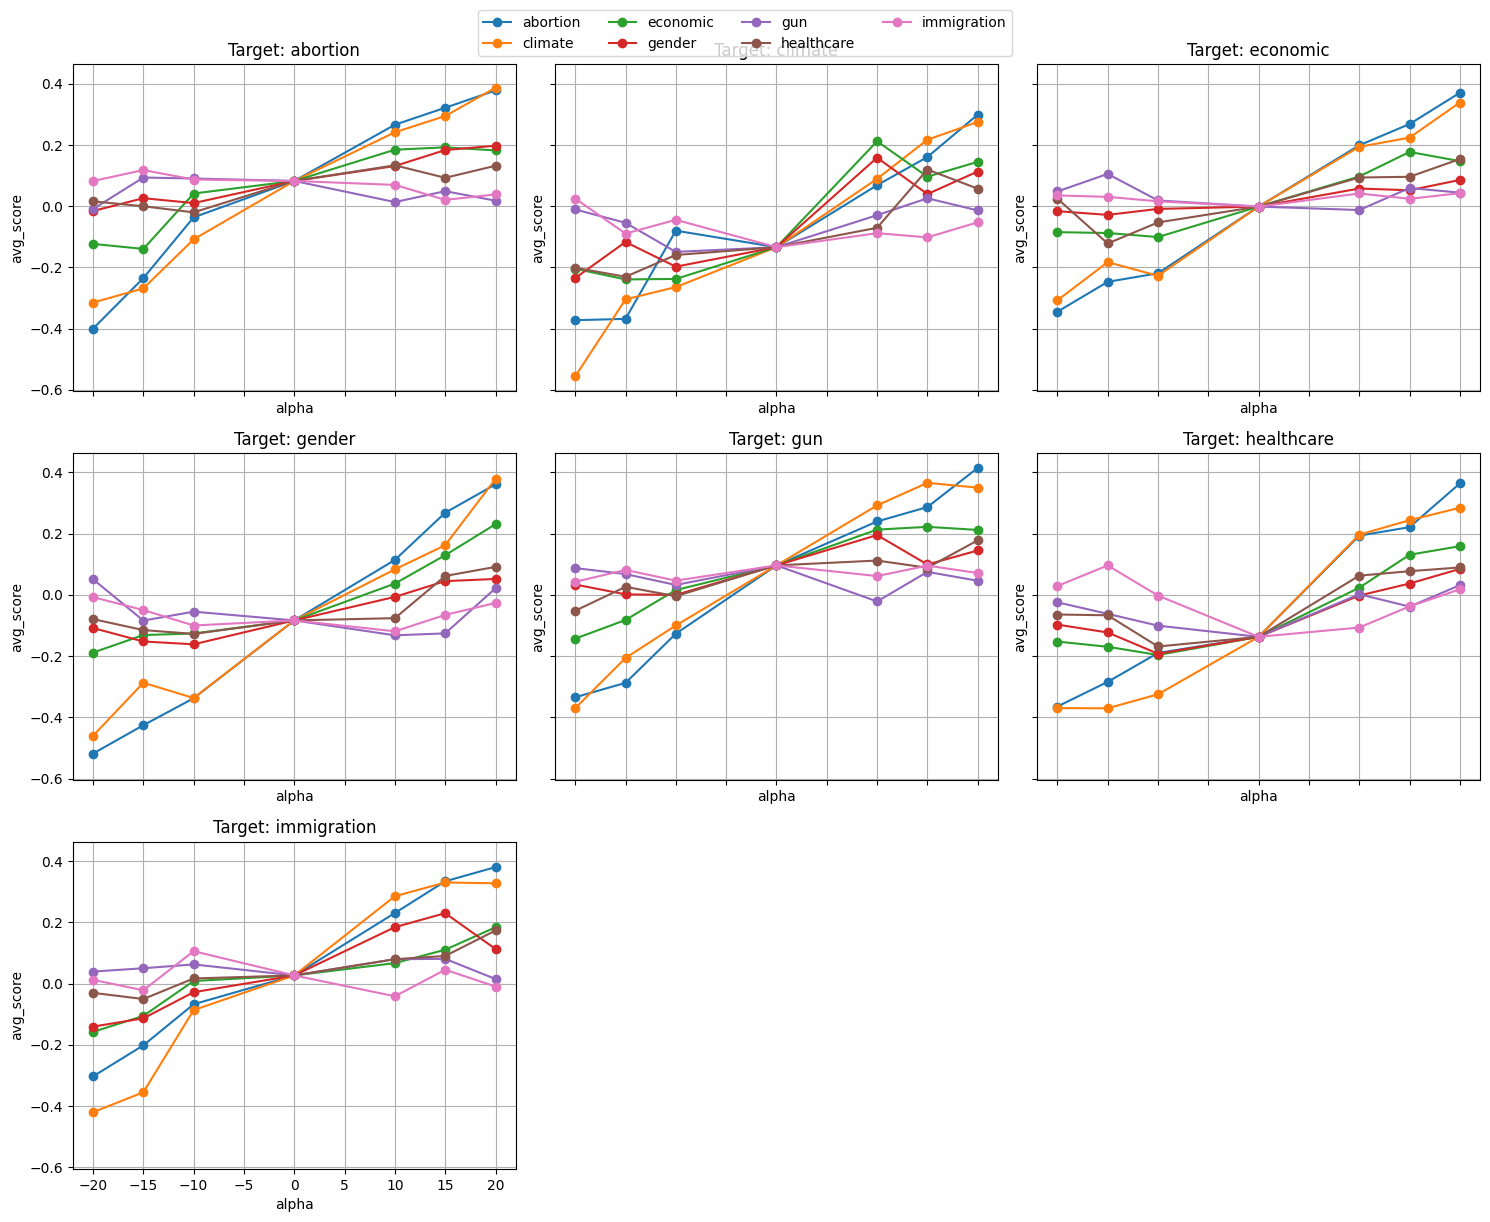

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "./results"
CSV_PATH = os.path.join(RESULTS_DIR, "cross_domain_alpha_avg_scores.csv")

df = pd.read_csv(CSV_PATH)

# 1) Line plots: avg_score vs alpha, one subplot per target_domain, lines = intervention_domain
targets = sorted(df["target_domain"].unique())
interventions = sorted(df["intervention_domain"].unique())

ncols = 3
nrows = (len(targets) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, tgt in enumerate(targets):
    ax = axes[i]
    sub = df[df["target_domain"] == tgt]

    for inter in interventions:
        sub2 = sub[sub["intervention_domain"] == inter].sort_values("alpha")
        ax.plot(sub2["alpha"], sub2["avg_score"], marker="o", label=inter)

    ax.set_title(f"Target: {tgt}")
    ax.set_xlabel("alpha")
    ax.set_ylabel("avg_score")
    ax.grid(True)

# Hide any unused axes
for j in range(len(targets), len(axes)):
    axes[j].axis("off")

# Put a single legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(interventions), 4), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

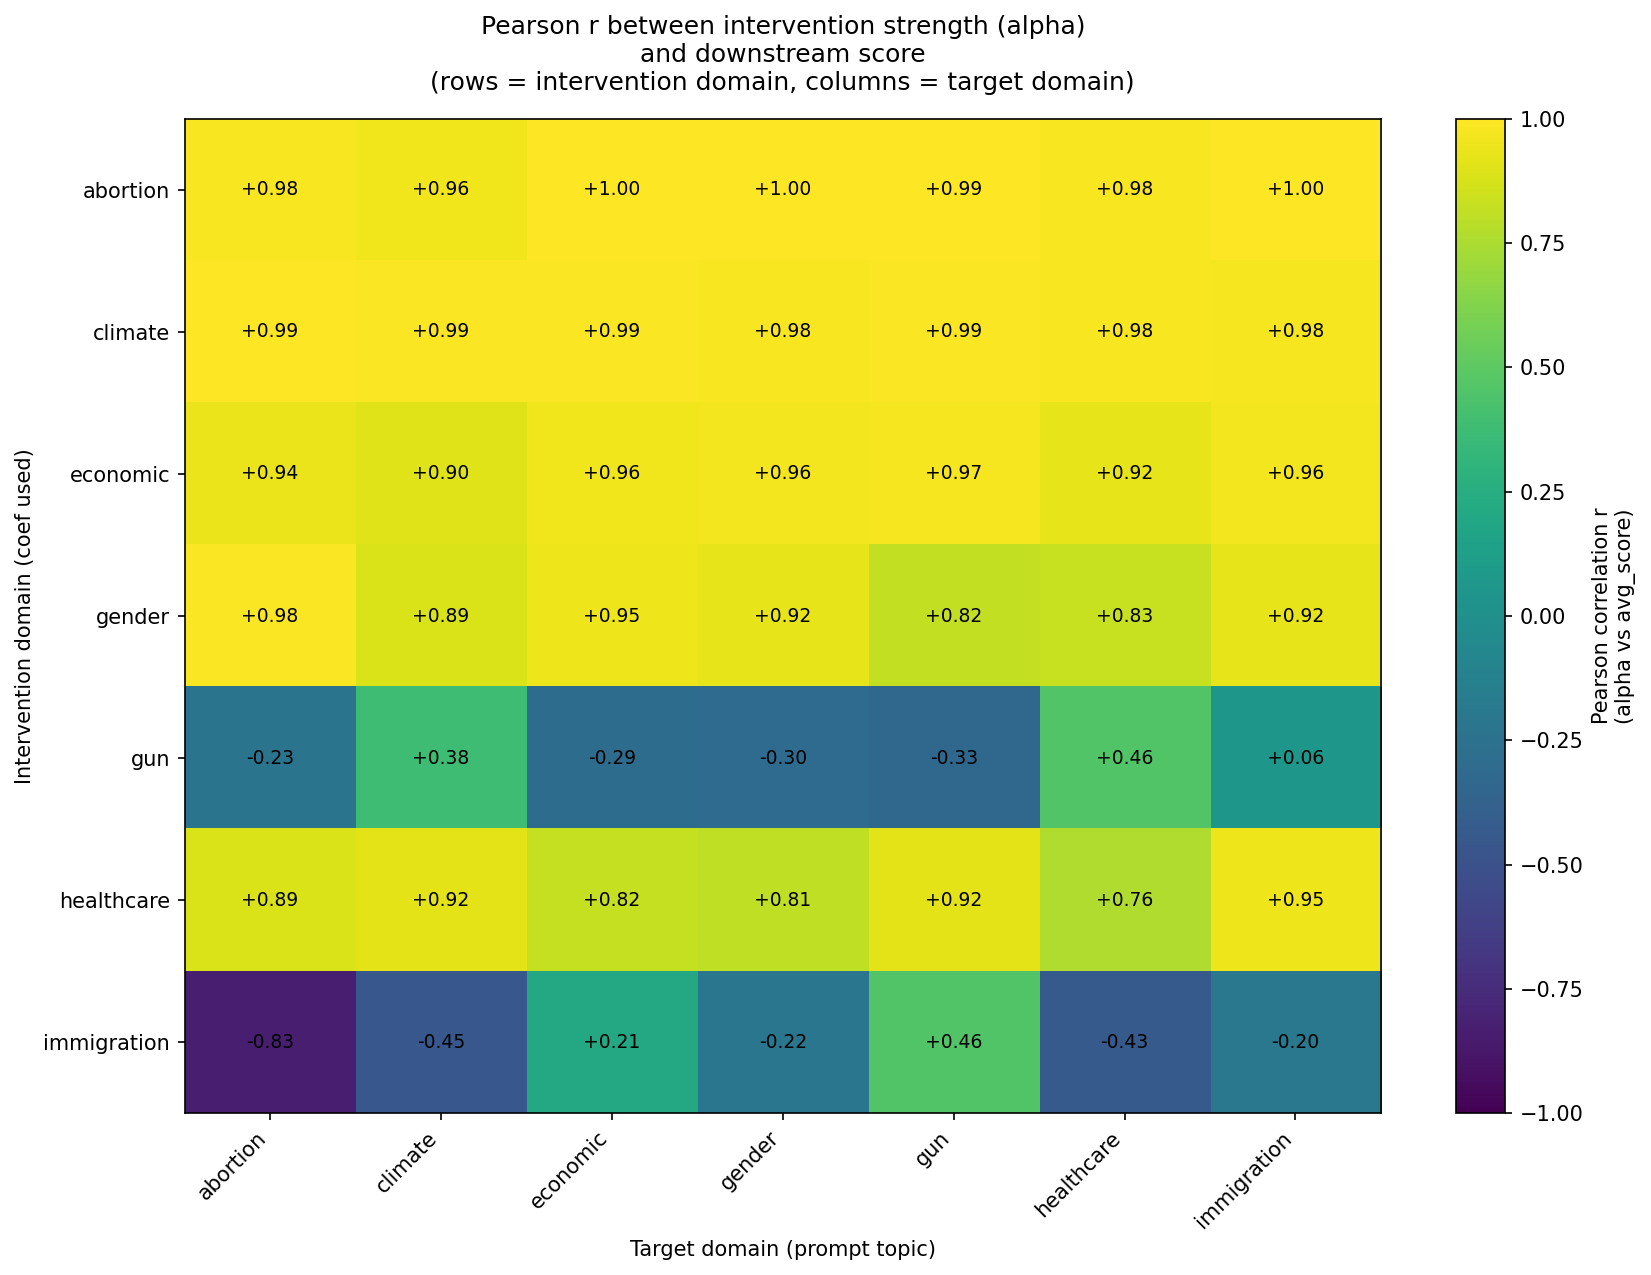

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "./results"
CSV_PATH = os.path.join(RESULTS_DIR, "cross_domain_alpha_avg_scores.csv")

df = pd.read_csv(CSV_PATH)

# Pearson corr(alpha, avg_score) for each (intervention_domain, target_domain)
corr_df = (
    df.groupby(["intervention_domain", "target_domain"])
      .apply(lambda g: g["alpha"].corr(g["avg_score"], method="pearson"))
      .reset_index(name="pearson_r")
)

# Pivot into matrix for a heatmap-style plot (no seaborn)
interventions = sorted(corr_df["intervention_domain"].unique())
targets = sorted(corr_df["target_domain"].unique())

mat = (
    corr_df.pivot(index="intervention_domain", columns="target_domain", values="pearson_r")
           .reindex(index=interventions, columns=targets)
)

fig, ax = plt.subplots(
    figsize=(1.2 * len(targets) + 3, 0.8 * len(interventions) + 3), dpi=150
)

im = ax.imshow(mat.values, aspect="auto", vmin=-1, vmax=1)

# --- Titles & axis labels (explicit semantics) ---
ax.set_title(
    "Pearson r between intervention strength (alpha)\n"
    "and downstream score\n"
    "(rows = intervention domain, columns = target domain)",
    pad=14,
)

ax.set_xlabel("Target domain (prompt topic)")
ax.set_ylabel("Intervention domain (coef used)")

# --- Ticks ---
ax.set_xticks(range(len(targets)))
ax.set_xticklabels(targets, rotation=45, ha="right")

ax.set_yticks(range(len(interventions)))
ax.set_yticklabels(interventions)

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation r\n(alpha vs avg_score)")

# --- Annotate cells ---
for r in range(mat.shape[0]):
    for c in range(mat.shape[1]):
        v = mat.values[r, c]
        if not np.isnan(v):
            ax.text(
                c,
                r,
                f"{v:+.2f}",
                ha="center",
                va="center",
                fontsize=9,
            )

fig.tight_layout()
plt.show()

### Domain probe scoring

In [19]:
import os
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

DOMAINS = ['abortion', 'gender', 'immigration', 'healthcare', 'economic', 'climate', 'gun']

# Intervention knobs
ALPHAS = [-20, -15, -10, 0, 10, 15, 20]
MAX_NEW_TOKENS = 200
K = 16

# Prefix templates
COEF_PREFIX_TEMPLATE = "integrated_{domain}"   # steering coefs live here
RIDGE_PREFIX_TEMPLATE = "integrated_{domain}"             # scoring ridge models live here (change if yours differ!)

RESULTS_DIR = "./results"
OUT_CSV = os.path.join(RESULTS_DIR, "steer_general_prompt_score_all_domains.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Prompt is now constant (no domain mention)
PROMPT = "USER: Generate a statement by an average US politician in 2019?\nASSISTANT: "

# ---------- Load base model once ----------
model_path = MODELS[0]
tokenizer, model = load_tokenizer_and_model(model_path, device=device)

def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().float().cpu().numpy()
    return np.asarray(x, dtype=np.float32)

# ---------- Precompute steering coefs for each intervention domain ----------
coefs_by_domain = {}
for intervention_domain in DOMAINS:
    coef_prefix = COEF_PREFIX_TEMPLATE.format(domain=intervention_domain)

    ridge_models, performance = load_ridge_models(model_path, prefix=coef_prefix)
    feats = load_feats(model_path, prefix=coef_prefix, results_dir=RESULTS_DIR, device=device)

    coefs = compute_combined_coefs(
        feats=feats,
        k=K,
        ridge_models=ridge_models,
        performance=performance,
        device=device,
    )
    coefs_by_domain[intervention_domain] = coefs

# ---------- Load scoring ridge models for each scoring domain ----------
scorers = {}
for score_domain in DOMAINS:
    ridge_prefix = RIDGE_PREFIX_TEMPLATE.format(domain=score_domain)
    s_ridge_models, s_performance = load_ridge_models(model_path, prefix=ridge_prefix)
    scorers[score_domain] = (s_ridge_models, s_performance)

# ---------- Run: steer with each domain, score with EVERY domain ridge ----------
rows = []

for intervention_domain, coefs in coefs_by_domain.items():
    for alpha in tqdm(ALPHAS, desc=f"Steering domain: {intervention_domain}"):
        # 1) Generate once per (intervention_domain, alpha)
        res = generate_with_head_intervention_gpu(
            model,
            tokenizer,
            prompts=PROMPT,
            alpha=alpha,
            max_new_tokens=MAX_NEW_TOKENS,
            combined_coefs=coefs,
            return_features=True,
            device=device,
        )

        # 2) Score the SAME generated result with each scoring-domain ridge
        for score_domain in DOMAINS:
            s_ridge_models, s_performance = scorers[score_domain]

            scores_obj = predict_per_token_scores(
                results=res,
                ridge_models=s_ridge_models,
                performance=s_performance,
                k=K,
            )

            # Adjust if your predict_per_token_scores output structure differs
            token_scores = scores_obj[0]["scores"]
            avg_score = float(np.mean(_to_numpy(token_scores)))

            rows.append({
                "intervention_domain": intervention_domain,  # which steering coefs used
                "alpha": alpha,
                "score_domain": score_domain,                # which ridge we scored with
                "avg_score": avg_score,
            })

df = (
    pd.DataFrame(rows)
      .sort_values(["intervention_domain", "alpha", "score_domain"])
      .reset_index(drop=True)
)
df.to_csv(OUT_CSV, index=False)

print(f"Saved: {OUT_CSV}")
display(df.head(30))


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Steering domain: gun: 100%|██████████| 7/7 [00:44<00:00,  6.41s/it]

Saved: ./results/steer_general_prompt_score_all_domains.csv


,intervention_domain,alpha,score_domain,avg_score
0,abortion,-20,abortion,-15.252035
1,abortion,-20,climate,-1.099402
2,abortion,-20,economic,-1.627617
3,abortion,-20,gender,-1.080263
4,abortion,-20,gun,-0.533065
5,abortion,-20,healthcare,-1.125004
6,abortion,-20,immigration,-1.772477
7,abortion,-15,abortion,-11.450527
8,abortion,-15,climate,-0.821496
9,abortion,-15,economic,-1.263452


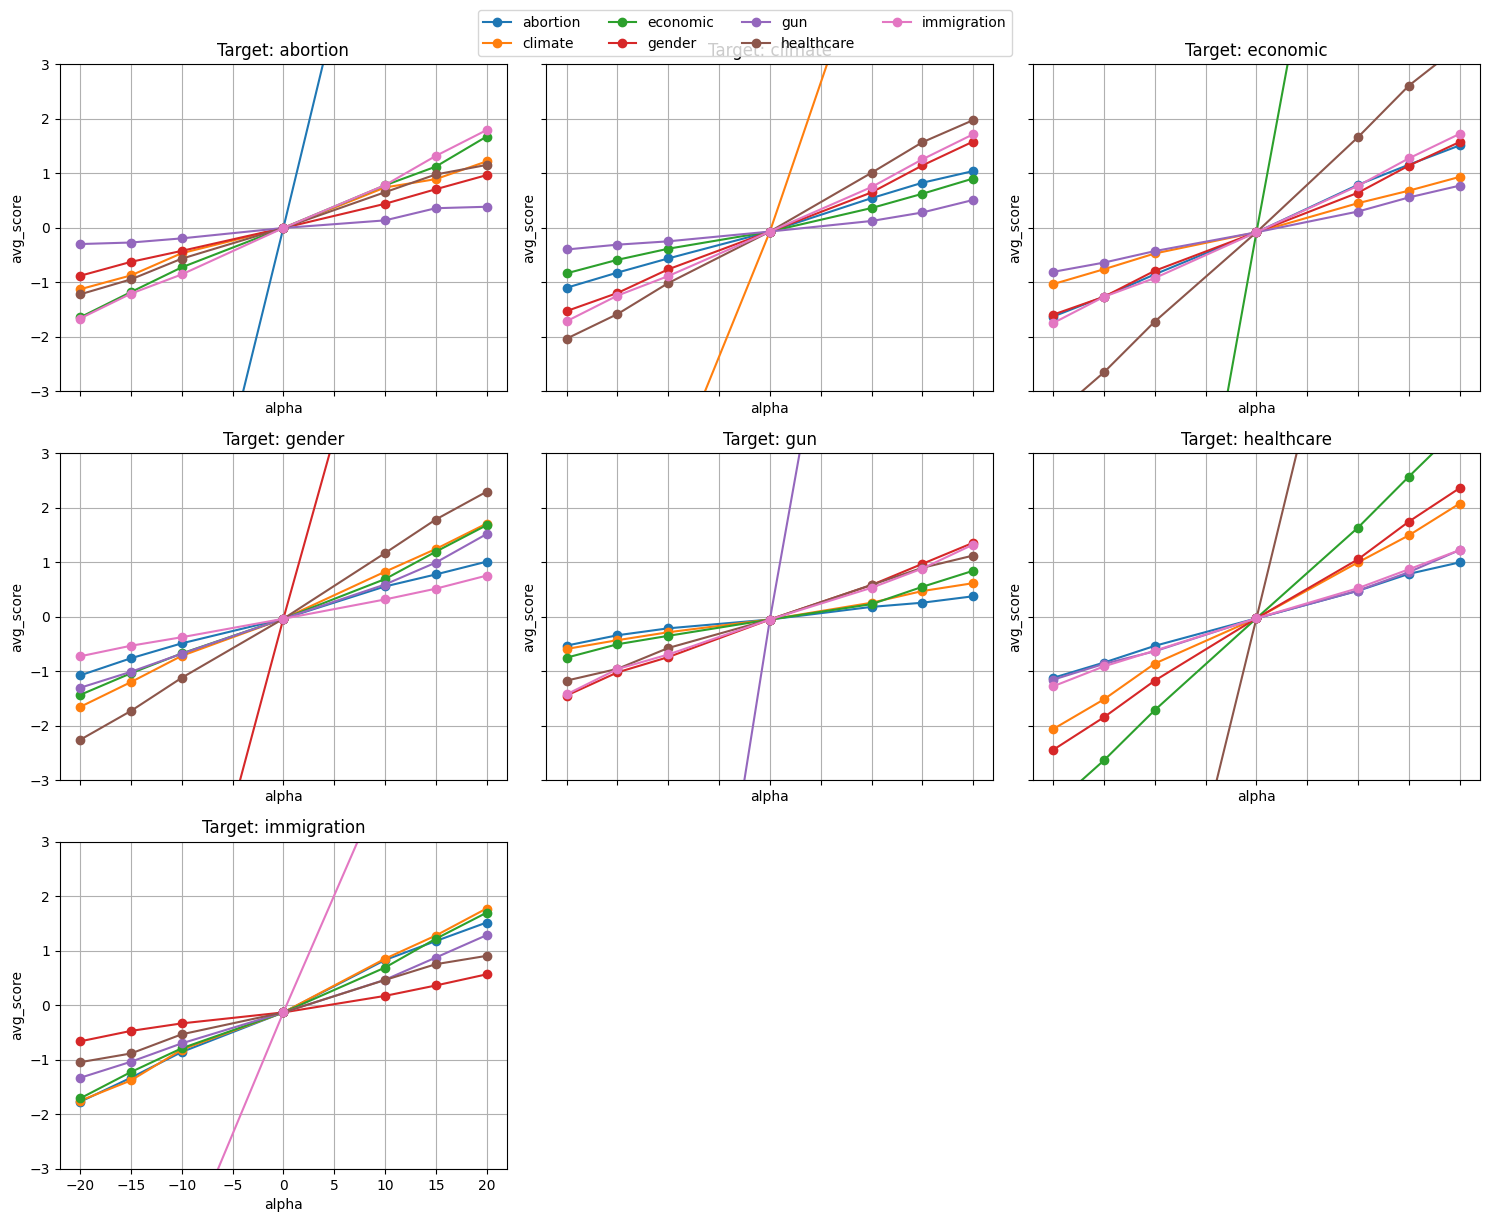

In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "./results"
CSV_PATH = os.path.join(RESULTS_DIR, "steer_general_prompt_score_all_domains.csv")

df = pd.read_csv(CSV_PATH)

# 1) Line plots: avg_score vs alpha, one subplot per target_domain, lines = intervention_domain
targets = sorted(df["score_domain"].unique())
interventions = sorted(df["intervention_domain"].unique())

ncols = 3
nrows = (len(targets) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, tgt in enumerate(targets):
    ax = axes[i]
    sub = df[df["score_domain"] == tgt]

    for inter in interventions:
        sub2 = sub[sub["intervention_domain"] == inter].sort_values("alpha")
        ax.plot(sub2["alpha"], sub2["avg_score"], marker="o", label=inter)
        ax.set_ylim(-3, 3)

    ax.set_title(f"Target: {tgt}")
    ax.set_xlabel("alpha")
    ax.set_ylabel("avg_score")
    ax.grid(True)

# Hide any unused axes
for j in range(len(targets), len(axes)):
    axes[j].axis("off")

# Put a single legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(interventions), 4), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

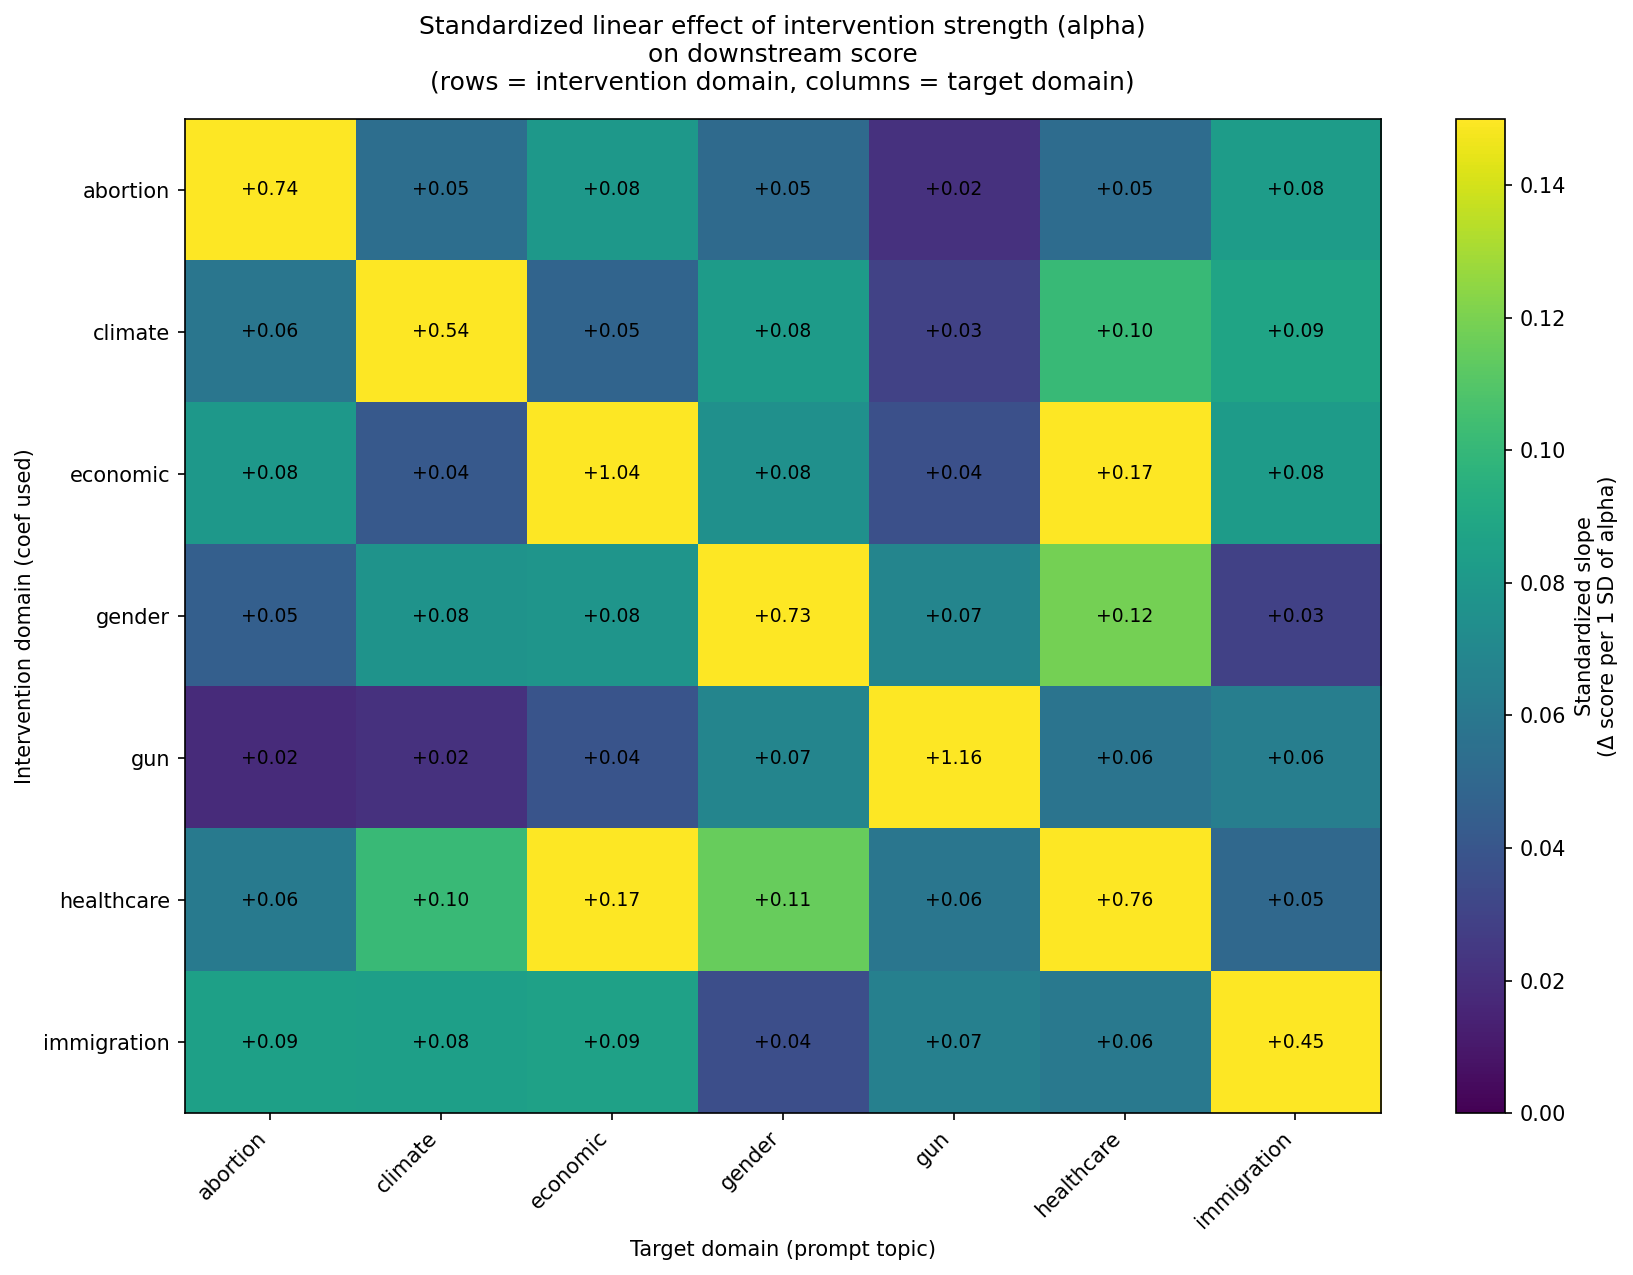

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "./results"
CSV_PATH = os.path.join(RESULTS_DIR, "steer_general_prompt_score_all_domains.csv")

df = pd.read_csv(CSV_PATH)

def standardized_slope(g):
    x = g["alpha"].values
    y = g["avg_score"].values

    # Fit y = beta * x + intercept
    beta, _ = np.polyfit(x, y, 1)

    # Standardize
    x_std = np.std(x, ddof=0)
    y_std = np.std(y, ddof=0)

    if y_std == 0:
        return np.nan

    return beta

# Compute standardized slope for each pair
slope_df = (
    df.groupby(["intervention_domain", "score_domain"])
      .apply(standardized_slope)
      .reset_index(name="std_slope")
)

# Pivot into matrix for heatmap
interventions = sorted(slope_df["intervention_domain"].unique())
targets = sorted(slope_df["score_domain"].unique())

mat = (
    slope_df.pivot(index="intervention_domain",
                   columns="score_domain",
                   values="std_slope")
            .reindex(index=interventions, columns=targets)
)

fig, ax = plt.subplots(
    figsize=(1.2 * len(targets) + 3, 0.8 * len(interventions) + 3),
    dpi=150,
)

im = ax.imshow(
    mat.values,
    aspect="auto",
    vmin=0.0,
    vmax=0.15,
)

# --- Titles & axis labels ---
ax.set_title(
    "Standardized linear effect of intervention strength (alpha)\n"
    "on downstream score\n"
    "(rows = intervention domain, columns = target domain)",
    pad=14,
)

ax.set_xlabel("Target domain (prompt topic)")
ax.set_ylabel("Intervention domain (coef used)")

# --- Ticks ---
ax.set_xticks(range(len(targets)))
ax.set_xticklabels(targets, rotation=45, ha="right")

ax.set_yticks(range(len(interventions)))
ax.set_yticklabels(interventions)

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Standardized slope\n(Δ score per 1 SD of alpha)")

# --- Annotate cells ---
for r in range(mat.shape[0]):
    for c in range(mat.shape[1]):
        v = mat.values[r, c]
        if not np.isnan(v):
            ax.text(
                c,
                r,
                f"{v:+.2f}",
                ha="center",
                va="center",
                fontsize=9,
            )

fig.tight_layout()
plt.show()
